Here I'll list some known events

| Biome                                 | Coordinates (x, y)        | Pixel Range |
|---------------------------------------|---------------------------|-------------|
| Lowland broadleaf                     | 2694491.82, 1126023.20    | 0–24        |
| Highland broadleaf                    | 2692020.28, 1121443.47    | 25–49       |
| Lowland evergreen                     | 2761097.61, 1194613.45    | 50–74       |
| Highland evergreen                    | 2781537.00, 1182975.00    | 75–99       |
| Biscth fire affected area             | 2644008.20, 1133794.76    | 100–124     |
| Biscth fire nearby non-affected area  | 2644328.07, 1134342.81    | 125–149     |
| Drought-affected area                 | 2690025.48, 1287413.03    | 150–174     |
| Burlgim storm affected area           | —                         | 175–199     |

In [1]:
# library loading, nothing interesting
from IPython.display import IFrame, Image, display
import numpy as np
import math
import zarr
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import xarray as xr
import torch
import torch.nn as nn
import pandas as pd
import statsmodels.api as sm
import gc
import imageio
from io import BytesIO
from affine import Affine
import matplotlib.dates as mdates
from functions import *

In [2]:
# data loading and raster initialization
# ----- Config -----
zarr_path = "../pixel_biomes_2.zarr/ndvi"

z = zarr.open(zarr_path, mode="r")

# fitting and smoothing
# ----- seasonal cycle fitting -----
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")
ndvi = ds["ndvi"]
dates = ds["dates"]
params_lower = torch.tensor(ds["params_lower"].values)
params_upper = torch.tensor(ds["params_upper"].values)

# convert dates to doy
dates_pd = pd.to_datetime(dates)
df = pd.DataFrame({"date": dates_pd})
df_sorted = df.sort_values(by="date")
dates_sorted = df_sorted["date"].values
dates_pd_sorted = pd.to_datetime(dates_sorted)
doy = dates_pd_sorted.dayofyear.values
doy = torch.tensor(doy, dtype=torch.float32)
T_SCALE = 1.0 / 365.0
t = doy.unsqueeze(0).repeat(params_lower.shape[0], 1) * T_SCALE


lower = double_logistic_function(t[[0]], params_lower[[91]]).squeeze().cpu().numpy()
upper = double_logistic_function(t[[0]], params_upper[[91]]).squeeze().cpu().numpy()

median_iqr = upper - (upper - lower) / 2

param_iqr = 1.02
bottom_iqr = 0.2
upper_iqr = 0.8
window_length = 14
polyorder = 2

pixel = 20  # pick one pixel index to check

ndvi_series = z[pixel, :]

# proper sorting

df = pd.DataFrame({
    'date': dates_pd,
    'ndvi': ndvi_series
    })

df_sorted = df.sort_values(by='date')

ndvi_sorted = df_sorted['ndvi'].values

ndvi_gapfilled, outlier_arr, q_hi, q_low, delta_diff, iqr_param, smoothed,valid_outlier, valid_idx, deltas = gapfill_ndvi(ndvi_sorted, lower, upper,forecasting=False,
                                            param_iqr=1.02,bottom_q=0.4,
                                            top_q=0.6,return_quantiles = True, weight_median = 0.5,smoothing_method = "savgol")


y_delta_l , y_delta_h,r_delta_h, r_delta_l  = np.quantile(delta_diff, [0.2,0.8,0.9,0.05])
y_iqr, r_iqr = np.quantile(iqr_param, [0.4, 0.8])

# ----- Config -----
zarr_path = "../pixel_biomes.zarr/ndvi"
z = zarr.open(zarr_path, mode="r")

# load seasonal cycle parameters
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")

# pick one pixel
ndvi = z[pixel, :]  
dates = ds["dates"].values   # numpy datetime64

# clean and normalize NDVI
ndvi = ndvi.astype(float) / 10000.0
ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

# --- 1. Create initial df ---
df_starting = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "ndvi": ndvi
    })

# --- 2. Handle duplicate dates ---
df_starting = (
    df_starting.groupby("date", as_index=False)
    .mean(numeric_only=True)   # average if duplicates exist
    .set_index("date")
)

# --- 3. Reindex to full daily series ---
full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
df = df_starting.reindex(full_index)

# add forecast column for later use
df["forecast"] = np.nan
df["upper"] = np.nan
df["lower"] = np.nan
df["gapfilled"] = np.nan
df["outlier"] = False
df["delta_smoothed"] = np.nan
df["idx"] = np.arange(len(df))
df["deltas_L1"] = np.nan


df.index.name = "date"

# remove data veofre marh 2018
df = df.loc[df.index >= pd.Timestamp("2018-04-25")]

# --- run your function row by row ---
# need an inital condition
last_date =  None #pd.Timestamp("2018-04-25")
last_potential_date =None
deltas_arr = []
dates_delta_arr = []
# this is extra just for the plotting
latency = []
current_date_latency = []

for date in df.index[df.index >= pd.Timestamp("2018-04-26")]:
    last_date, last_potential_date_arr, deltas_arr, dates_delta_arr, latency,  current_date_latency = ndvi_continous_final_2(
        df=df,
        date=date,
        params_lower =  params_lower[[91]],
        params_upper =  params_upper[[91]],
        last_date=last_date,
        deltas_arr = deltas_arr,
        dates_delta_arr = dates_delta_arr,
        last_potential_date = last_potential_date,
        y_delta_l = y_delta_l, 
        y_delta_h = y_delta_h,
        r_delta_h = r_delta_h, 
        r_delta_l = r_delta_l,
        y_iqr= y_iqr, 
        r_iqr = r_iqr,
        tau = 45,
        smoothing_values = 7,
        latency = latency,
        current_date_latency = current_date_latency

    )


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


Lowland brodaleaf

/tmp/ipykernel_2324571/1002697719.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


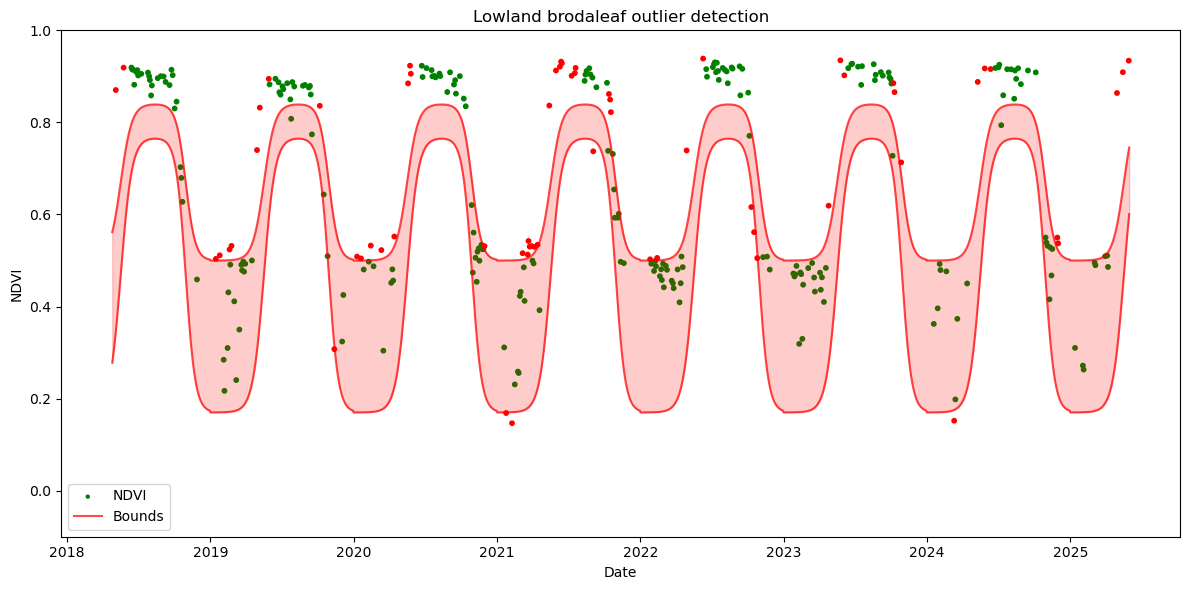

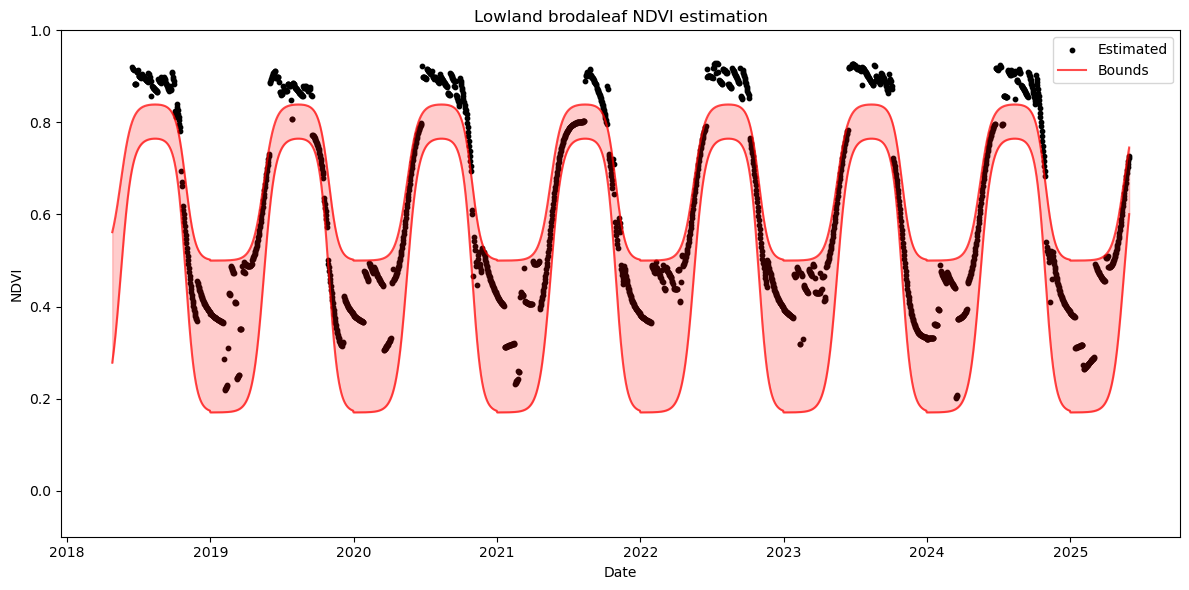

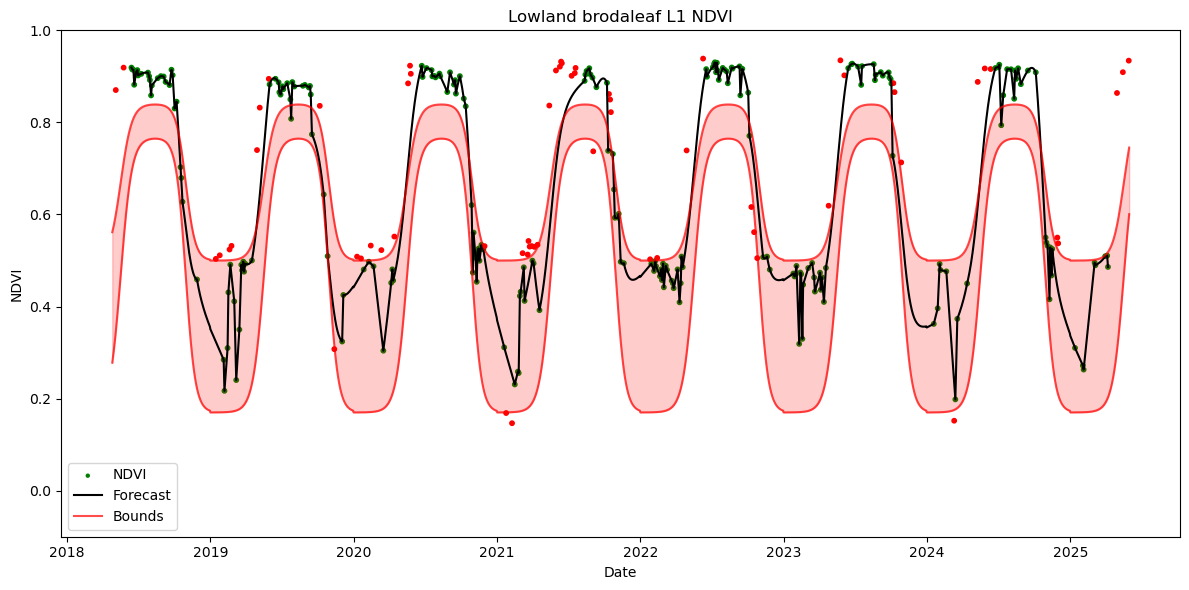

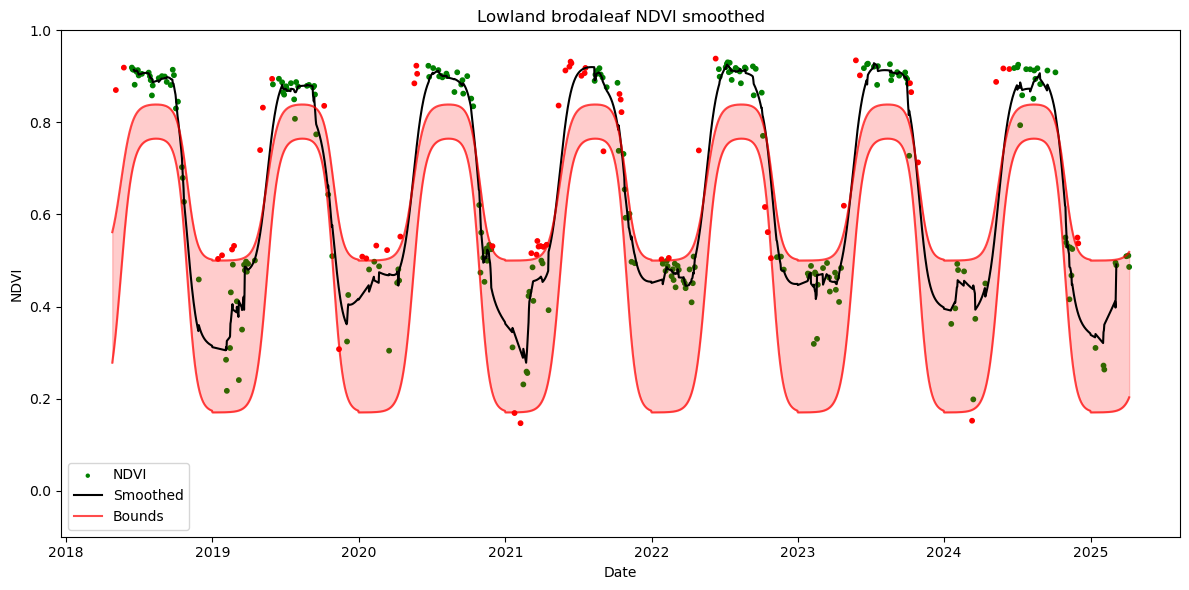

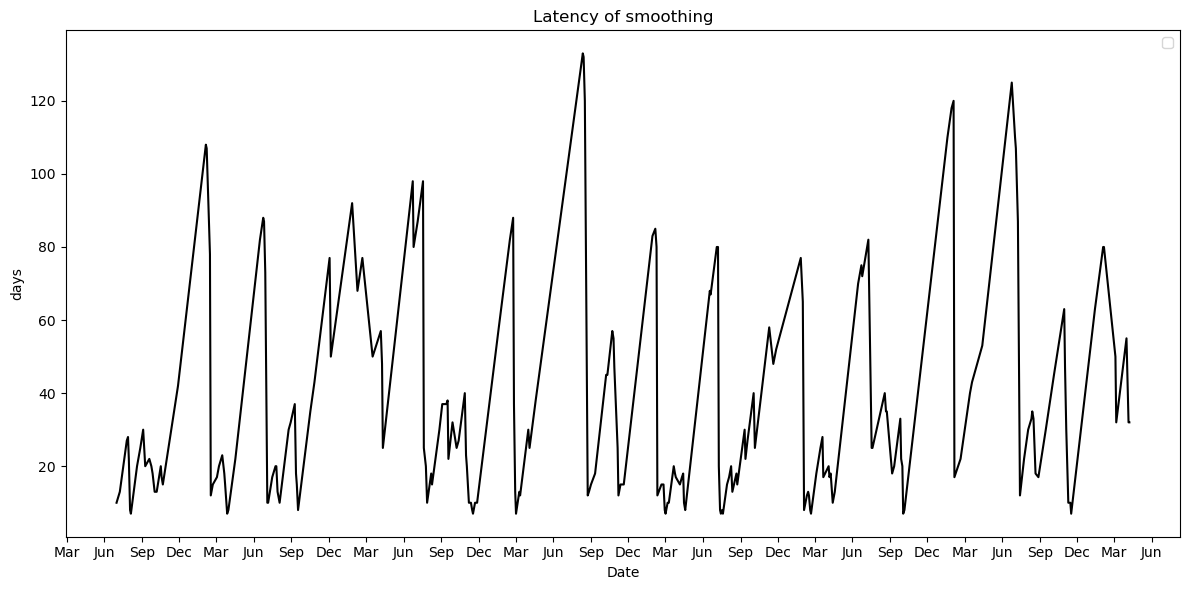

In [3]:

# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

# NDVI as green points
color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Lowland brodaleaf outlier detection")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

#ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.scatter(df_plot.index, df_plot["forecast"], color='black', label='Estimated', s=10)
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Lowland brodaleaf NDVI estimation")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["deltas_L1"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Forecast')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Lowland brodaleaf L1 NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed

# Crop df_plot to that date
df_plot = df[(df.index >= "2018-04-20") & (df.index <=  df[df["outlier"] == False].index.max())]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Smoothed')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Lowland brodaleaf NDVI smoothed")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots(figsize=(12, 6))

# Forecast as black points
ax.plot(current_date_latency, latency, color="black")

# Format x-axis to show ticks every 3 months with month names only
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Latency of smoothing")
ax.set_xlabel("Date")
ax.set_ylabel("days")
ax.legend()
plt.tight_layout()
plt.show()


In [4]:
# data loading and raster initialization
# ----- Config -----
zarr_path = "../pixel_biomes_2.zarr/ndvi"

z = zarr.open(zarr_path, mode="r")

# fitting and smoothing
# ----- seasonal cycle fitting -----
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")
ndvi = ds["ndvi"]
dates = ds["dates"]
params_lower = torch.tensor(ds["params_lower"].values)
params_upper = torch.tensor(ds["params_upper"].values)

# convert dates to doy
dates_pd = pd.to_datetime(dates)
df = pd.DataFrame({"date": dates_pd})
df_sorted = df.sort_values(by="date")
dates_sorted = df_sorted["date"].values
dates_pd_sorted = pd.to_datetime(dates_sorted)
doy = dates_pd_sorted.dayofyear.values
doy = torch.tensor(doy, dtype=torch.float32)
T_SCALE = 1.0 / 365.0
t = doy.unsqueeze(0).repeat(params_lower.shape[0], 1) * T_SCALE


lower = double_logistic_function(t[[0]], params_lower[[91]]).squeeze().cpu().numpy()
upper = double_logistic_function(t[[0]], params_upper[[91]]).squeeze().cpu().numpy()

median_iqr = upper - (upper - lower) / 2

param_iqr = 1.02
bottom_iqr = 0.2
upper_iqr = 0.8
window_length = 14
polyorder = 2

pixel = 40  # pick one pixel index to check

ndvi_series = z[pixel, :]

# proper sorting

df = pd.DataFrame({
    'date': dates_pd,
    'ndvi': ndvi_series
    })

df_sorted = df.sort_values(by='date')

ndvi_sorted = df_sorted['ndvi'].values

ndvi_gapfilled, outlier_arr, q_hi, q_low, delta_diff, iqr_param, smoothed,valid_outlier, valid_idx, deltas = gapfill_ndvi(ndvi_sorted, lower, upper,forecasting=False,
                                            param_iqr=1.02,bottom_q=0.4,
                                            top_q=0.6,return_quantiles = True, weight_median = 0.5,smoothing_method = "savgol")


y_delta_l , y_delta_h,r_delta_h, r_delta_l  = np.quantile(delta_diff, [0.2,0.8,0.95,0.05])
y_iqr, r_iqr = np.quantile(iqr_param, [0.6, 0.8])

# ----- Config -----
zarr_path = "../pixel_biomes.zarr/ndvi"
z = zarr.open(zarr_path, mode="r")

# load seasonal cycle parameters
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")

# pick one pixel
ndvi = z[pixel, :]  
dates = ds["dates"].values   # numpy datetime64

# clean and normalize NDVI
ndvi = ndvi.astype(float) / 10000.0
ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

# --- 1. Create initial df ---
df_starting = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "ndvi": ndvi
    })

# --- 2. Handle duplicate dates ---
df_starting = (
    df_starting.groupby("date", as_index=False)
    .mean(numeric_only=True)   # average if duplicates exist
    .set_index("date")
)

# --- 3. Reindex to full daily series ---
full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
df = df_starting.reindex(full_index)

# add forecast column for later use
df["forecast"] = np.nan
df["upper"] = np.nan
df["lower"] = np.nan
df["gapfilled"] = np.nan
df["outlier"] = False
df["delta_smoothed"] = np.nan
df["idx"] = np.arange(len(df))
df["deltas_L1"] = np.nan


df.index.name = "date"

# remove data veofre marh 2018
df = df.loc[df.index >= pd.Timestamp("2018-04-25")]

# --- run your function row by row ---
# need an inital condition
last_date =  None #pd.Timestamp("2018-04-25")
last_potential_date =None
deltas_arr = []
dates_delta_arr = []
# this is extra just for the plotting
latency = []
current_date_latency = []

for date in df.index[df.index >= pd.Timestamp("2018-04-26")]:
    last_date, last_potential_date_arr, deltas_arr, dates_delta_arr, latency,  current_date_latency = ndvi_continous_final_2(
        df=df,
        date=date,
        params_lower =  params_lower[[91]],
        params_upper =  params_upper[[91]],
        last_date=last_date,
        deltas_arr = deltas_arr,
        dates_delta_arr = dates_delta_arr,
        last_potential_date = last_potential_date,
        y_delta_l = y_delta_l, 
        y_delta_h = y_delta_h,
        r_delta_h = r_delta_h, 
        r_delta_l = r_delta_l,
        y_iqr= y_iqr, 
        r_iqr = r_iqr,
        tau = 45,
        smoothing_values = 7,
        latency = latency,
        current_date_latency = current_date_latency

    )


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


/tmp/ipykernel_2324571/1176647559.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


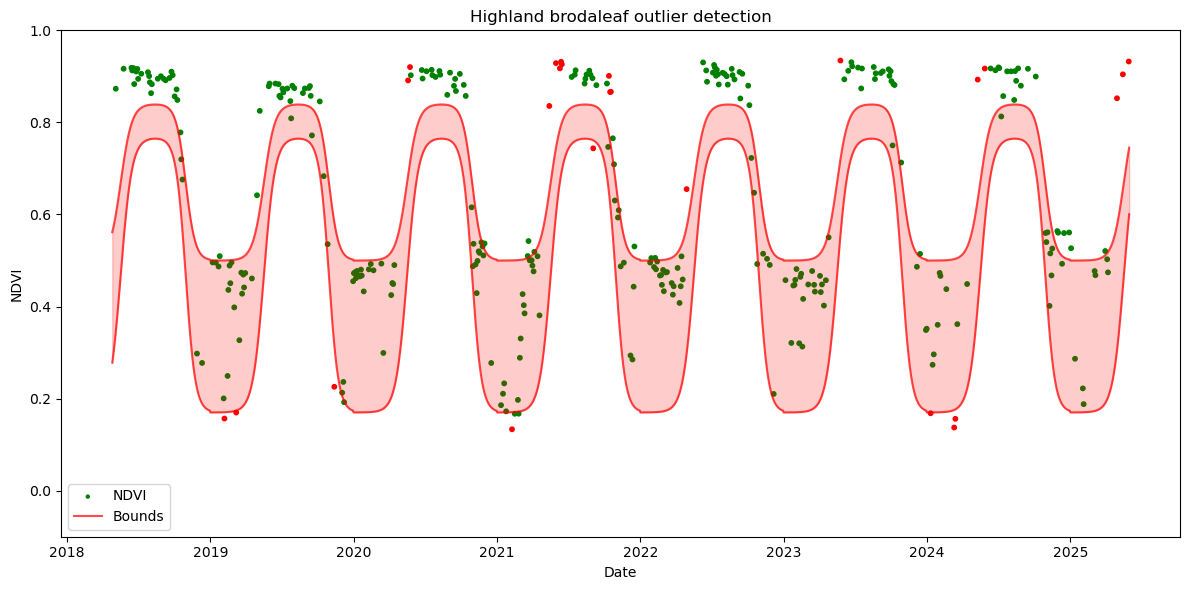

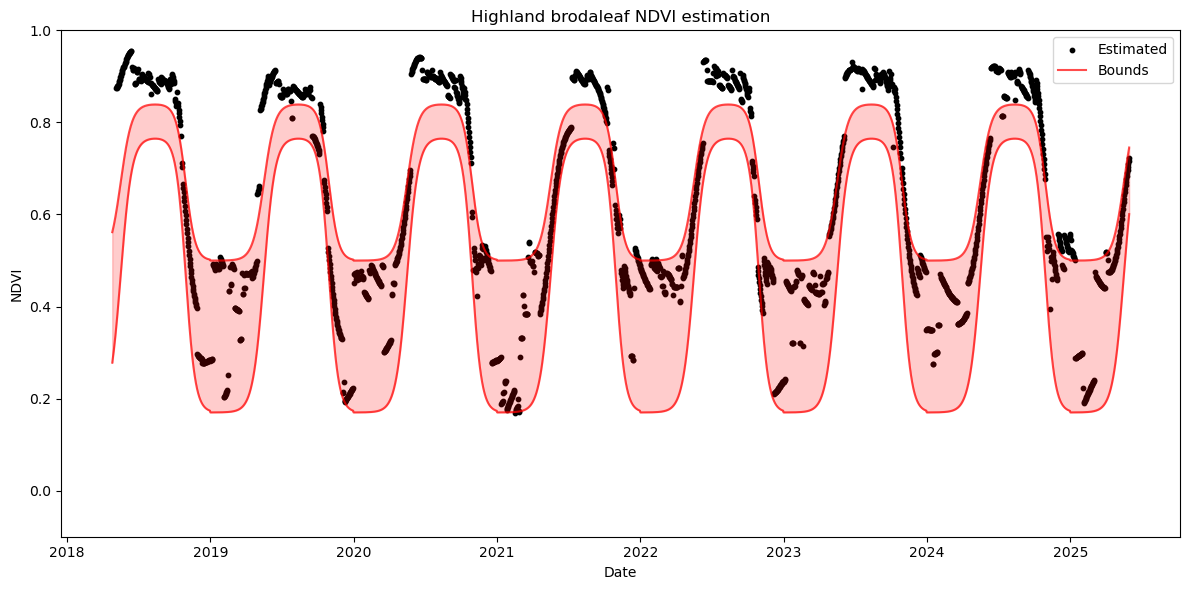

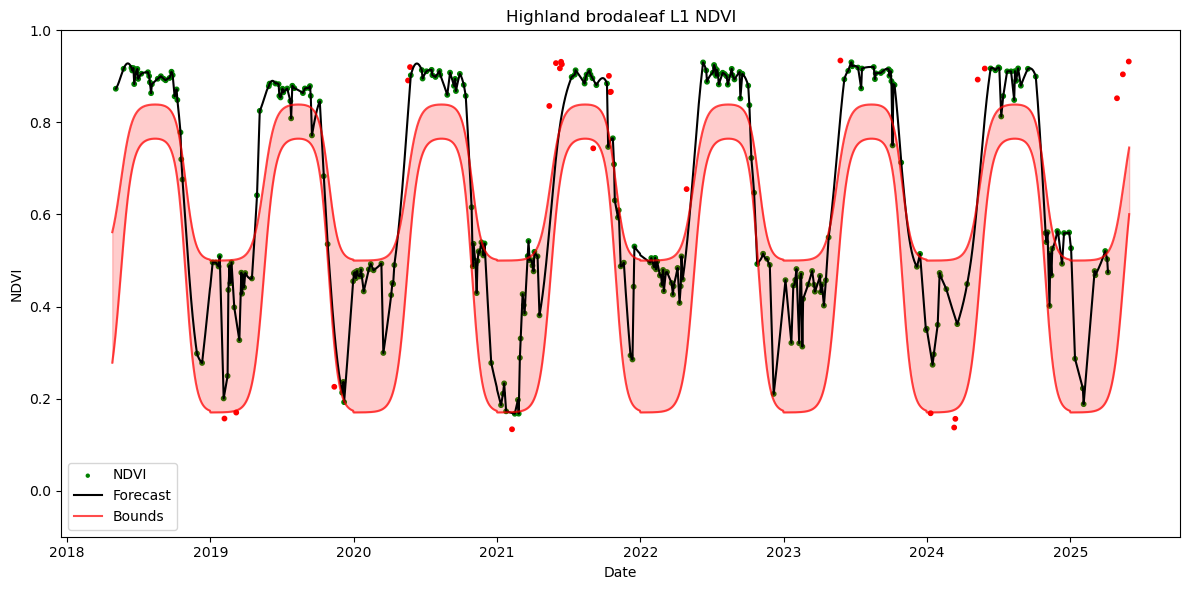

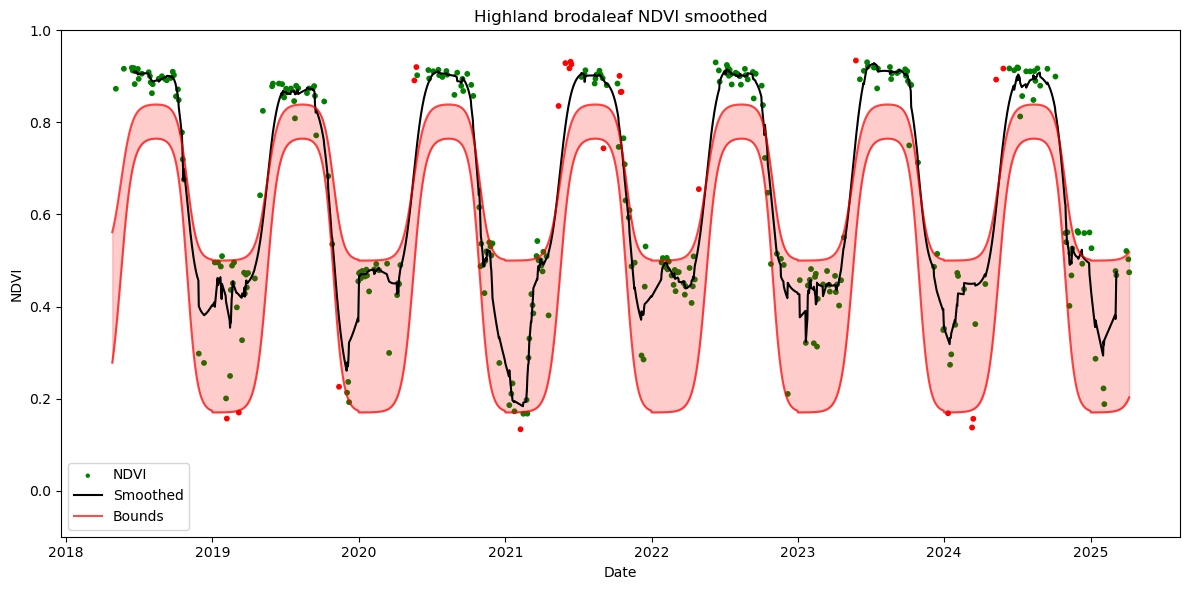

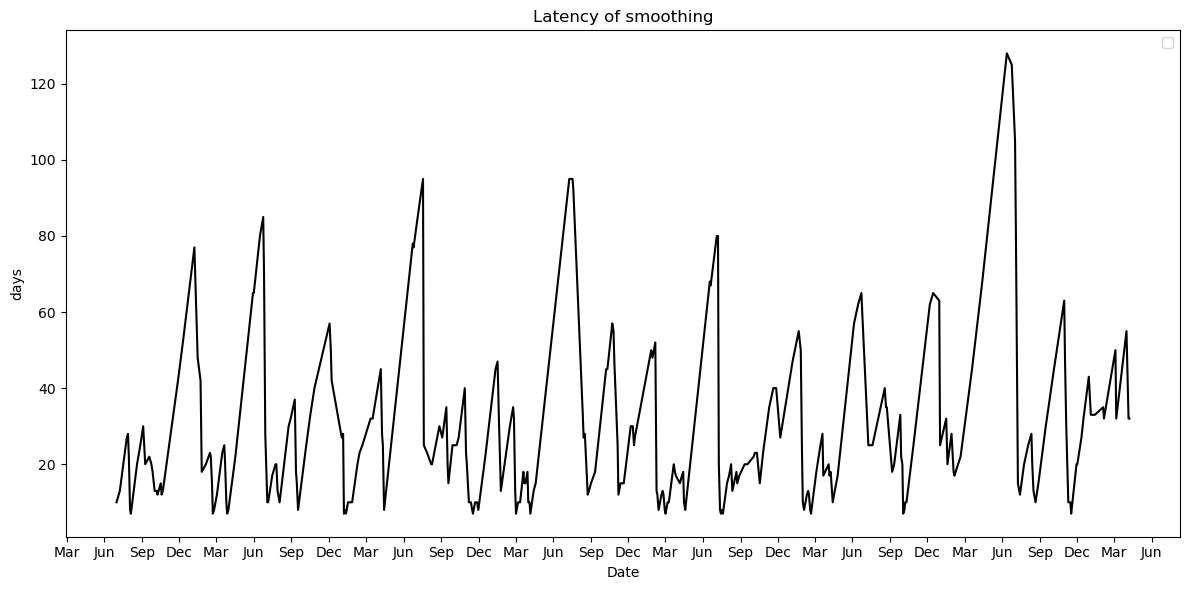

In [5]:

# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

# NDVI as green points
color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Highland brodaleaf outlier detection")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

#ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.scatter(df_plot.index, df_plot["forecast"], color='black', label='Estimated', s=10)
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Highland brodaleaf NDVI estimation")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["deltas_L1"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Forecast')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Highland brodaleaf L1 NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed

# Crop df_plot to that date
df_plot = df[(df.index >= "2018-04-20") & (df.index <=  df[df["outlier"] == False].index.max())]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Smoothed')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Highland brodaleaf NDVI smoothed")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots(figsize=(12, 6))

# Forecast as black points
ax.plot(current_date_latency, latency, color="black")

# Format x-axis to show ticks every 3 months with month names only
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Latency of smoothing")
ax.set_xlabel("Date")
ax.set_ylabel("days")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# data loading and raster initialization
# ----- Config -----
zarr_path = "../pixel_biomes_2.zarr/ndvi"

z = zarr.open(zarr_path, mode="r")

# fitting and smoothing
# ----- seasonal cycle fitting -----
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")
ndvi = ds["ndvi"]
dates = ds["dates"]
params_lower = torch.tensor(ds["params_lower"].values)
params_upper = torch.tensor(ds["params_upper"].values)

# convert dates to doy
dates_pd = pd.to_datetime(dates)
df = pd.DataFrame({"date": dates_pd})
df_sorted = df.sort_values(by="date")
dates_sorted = df_sorted["date"].values
dates_pd_sorted = pd.to_datetime(dates_sorted)
doy = dates_pd_sorted.dayofyear.values
doy = torch.tensor(doy, dtype=torch.float32)
T_SCALE = 1.0 / 365.0
t = doy.unsqueeze(0).repeat(params_lower.shape[0], 1) * T_SCALE


lower = double_logistic_function(t[[0]], params_lower[[91]]).squeeze().cpu().numpy()
upper = double_logistic_function(t[[0]], params_upper[[91]]).squeeze().cpu().numpy()

median_iqr = upper - (upper - lower) / 2

param_iqr = 1.02
bottom_iqr = 0.2
upper_iqr = 0.8
window_length = 14
polyorder = 2

pixel = 60  # pick one pixel index to check

ndvi_series = z[pixel, :]

# proper sorting

df = pd.DataFrame({
    'date': dates_pd,
    'ndvi': ndvi_series
    })

df_sorted = df.sort_values(by='date')

ndvi_sorted = df_sorted['ndvi'].values

ndvi_gapfilled, outlier_arr, q_hi, q_low, delta_diff, iqr_param, smoothed,valid_outlier, valid_idx, deltas = gapfill_ndvi(ndvi_sorted, lower, upper,forecasting=False,
                                            param_iqr=1.02,bottom_q=0.4,
                                            top_q=0.6,return_quantiles = True, weight_median = 0.5,smoothing_method = "savgol")


y_delta_l , y_delta_h,r_delta_h, r_delta_l  = np.quantile(delta_diff, [0.2,0.8,0.95,0.05])
y_iqr, r_iqr = np.quantile(iqr_param, [0.6, 0.8])

# ----- Config -----
zarr_path = "../pixel_biomes.zarr/ndvi"
z = zarr.open(zarr_path, mode="r")

# load seasonal cycle parameters
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")

# pick one pixel
ndvi = z[pixel, :]  
dates = ds["dates"].values   # numpy datetime64

# clean and normalize NDVI
ndvi = ndvi.astype(float) / 10000.0
ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

# --- 1. Create initial df ---
df_starting = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "ndvi": ndvi
    })

# --- 2. Handle duplicate dates ---
df_starting = (
    df_starting.groupby("date", as_index=False)
    .mean(numeric_only=True)   # average if duplicates exist
    .set_index("date")
)

# --- 3. Reindex to full daily series ---
full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
df = df_starting.reindex(full_index)

# add forecast column for later use
df["forecast"] = np.nan
df["upper"] = np.nan
df["lower"] = np.nan
df["gapfilled"] = np.nan
df["outlier"] = False
df["delta_smoothed"] = np.nan
df["idx"] = np.arange(len(df))
df["deltas_L1"] = np.nan


df.index.name = "date"

# remove data veofre marh 2018
df = df.loc[df.index >= pd.Timestamp("2018-04-25")]

# --- run your function row by row ---
# need an inital condition
last_date =  None #pd.Timestamp("2018-04-25")
last_potential_date =None
deltas_arr = []
dates_delta_arr = []
# this is extra just for the plotting
latency = []
current_date_latency = []

for date in df.index[df.index >= pd.Timestamp("2018-04-26")]:
    last_date, last_potential_date_arr, deltas_arr, dates_delta_arr, latency,  current_date_latency = ndvi_continous_final_2(
        df=df,
        date=date,
        params_lower =  params_lower[[91]],
        params_upper =  params_upper[[91]],
        last_date=last_date,
        deltas_arr = deltas_arr,
        dates_delta_arr = dates_delta_arr,
        last_potential_date = last_potential_date,
        y_delta_l = y_delta_l, 
        y_delta_h = y_delta_h,
        r_delta_h = r_delta_h, 
        r_delta_l = r_delta_l,
        y_iqr= y_iqr, 
        r_iqr = r_iqr,
        tau = 45,
        smoothing_values = 7,
        latency = latency,
        current_date_latency = current_date_latency

    )


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


/tmp/ipykernel_2324571/3418475192.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


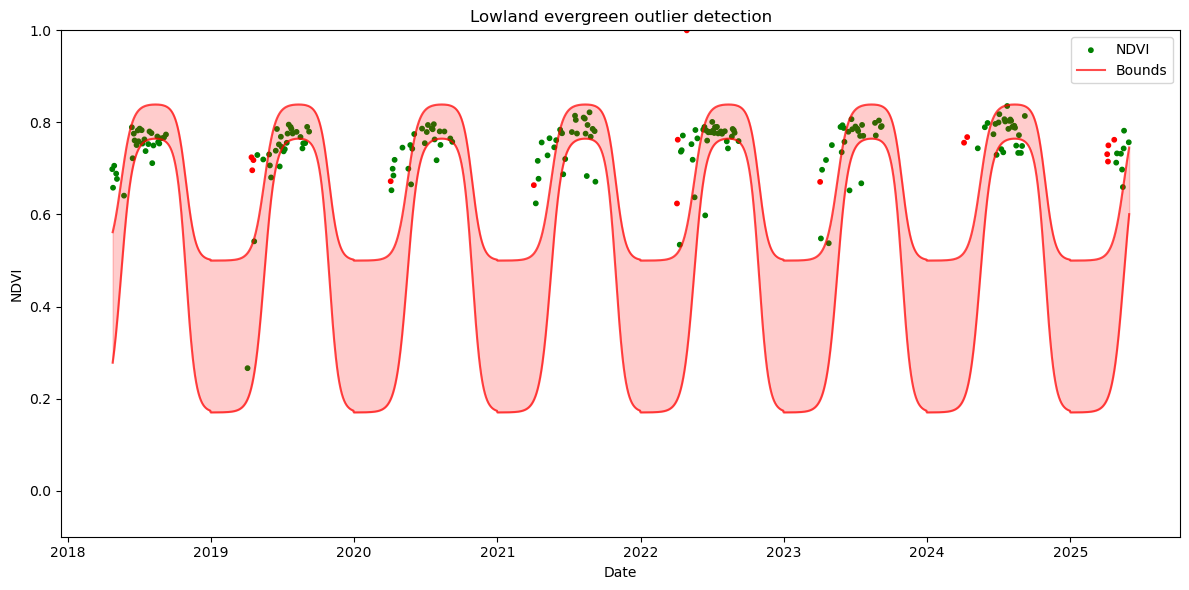

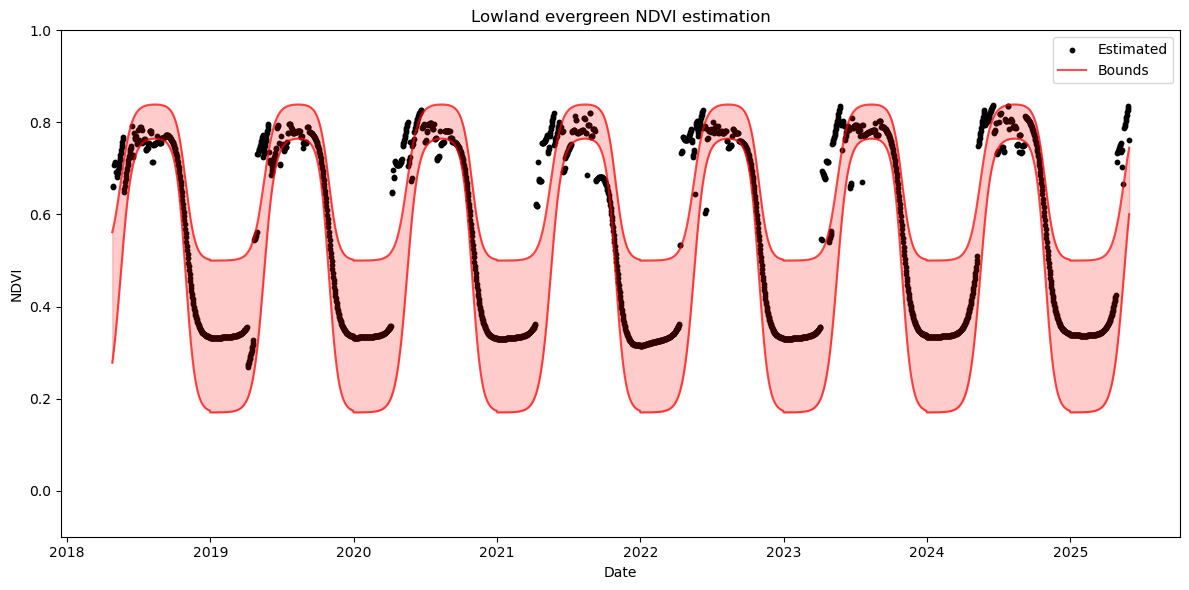

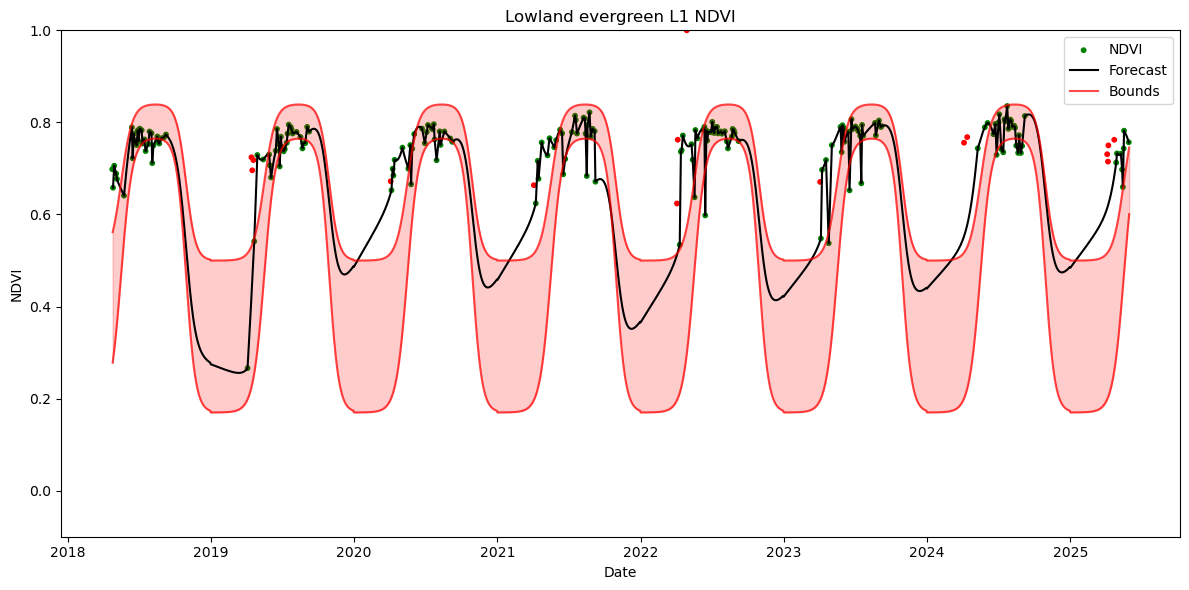

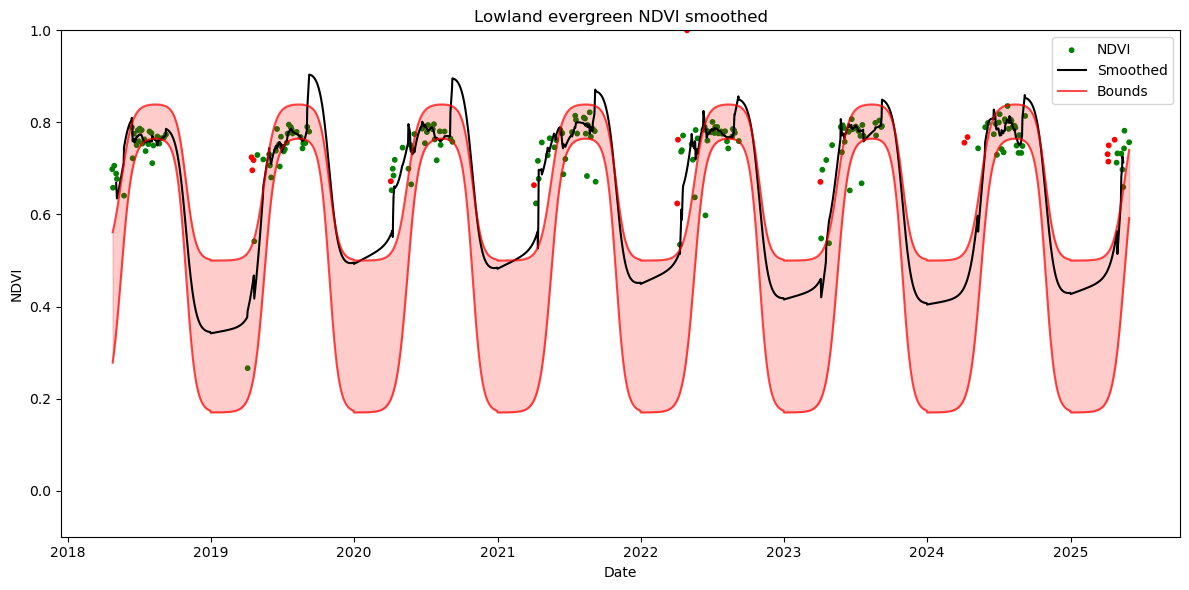

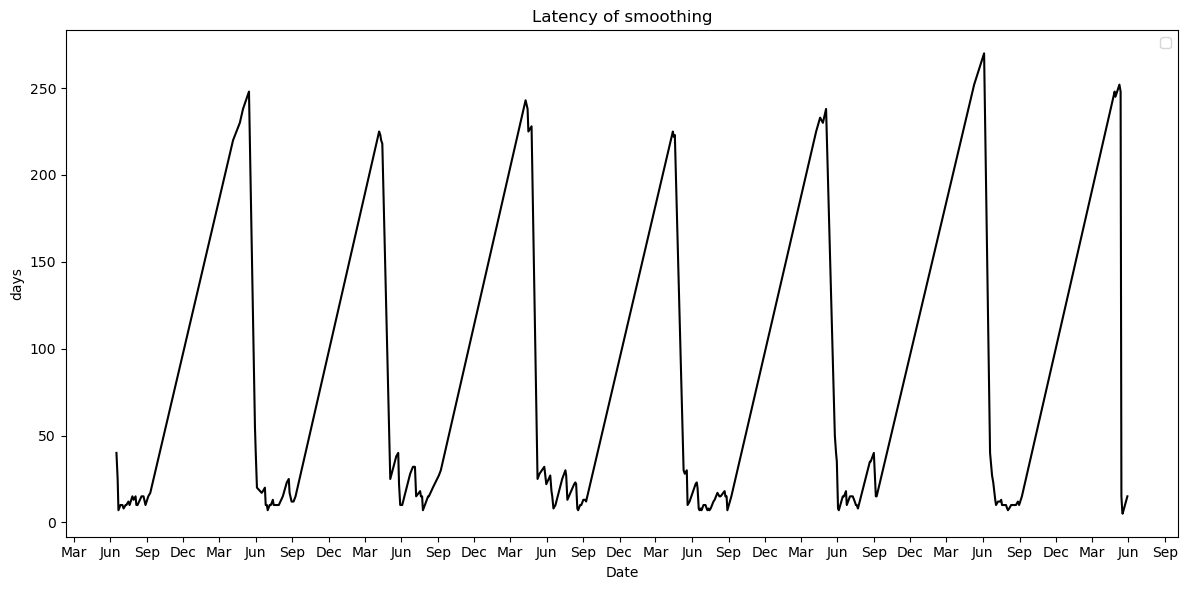

In [7]:

# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

# NDVI as green points
color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Lowland evergreen outlier detection")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

#ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.scatter(df_plot.index, df_plot["forecast"], color='black', label='Estimated', s=10)
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Lowland evergreen NDVI estimation")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["deltas_L1"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Forecast')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Lowland evergreen L1 NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed

# Crop df_plot to that date
df_plot = df[(df.index >= "2018-04-20") & (df.index <=  df[df["outlier"] == False].index.max())]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Smoothed')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Lowland evergreen NDVI smoothed")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots(figsize=(12, 6))

# Forecast as black points
ax.plot(current_date_latency, latency, color="black")

# Format x-axis to show ticks every 3 months with month names only
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Latency of smoothing")
ax.set_xlabel("Date")
ax.set_ylabel("days")
ax.legend()
plt.tight_layout()
plt.show()



In [8]:
# data loading and raster initialization
# ----- Config -----
zarr_path = "../pixel_biomes_2.zarr/ndvi"

z = zarr.open(zarr_path, mode="r")

# fitting and smoothing
# ----- seasonal cycle fitting -----
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")
ndvi = ds["ndvi"]
dates = ds["dates"]
params_lower = torch.tensor(ds["params_lower"].values)
params_upper = torch.tensor(ds["params_upper"].values)

# convert dates to doy
dates_pd = pd.to_datetime(dates)
df = pd.DataFrame({"date": dates_pd})
df_sorted = df.sort_values(by="date")
dates_sorted = df_sorted["date"].values
dates_pd_sorted = pd.to_datetime(dates_sorted)
doy = dates_pd_sorted.dayofyear.values
doy = torch.tensor(doy, dtype=torch.float32)
T_SCALE = 1.0 / 365.0
t = doy.unsqueeze(0).repeat(params_lower.shape[0], 1) * T_SCALE


lower = double_logistic_function(t[[0]], params_lower[[91]]).squeeze().cpu().numpy()
upper = double_logistic_function(t[[0]], params_upper[[91]]).squeeze().cpu().numpy()

median_iqr = upper - (upper - lower) / 2

param_iqr = 1.02
bottom_iqr = 0.2
upper_iqr = 0.8
window_length = 14
polyorder = 2

pixel = 80  # pick one pixel index to check

ndvi_series = z[pixel, :]

# proper sorting

df = pd.DataFrame({
    'date': dates_pd,
    'ndvi': ndvi_series
    })

df_sorted = df.sort_values(by='date')

ndvi_sorted = df_sorted['ndvi'].values

ndvi_gapfilled, outlier_arr, q_hi, q_low, delta_diff, iqr_param, smoothed,valid_outlier, valid_idx, deltas = gapfill_ndvi(ndvi_sorted, lower, upper,forecasting=False,
                                            param_iqr=1.02,bottom_q=0.4,
                                            top_q=0.6,return_quantiles = True, weight_median = 0.5,smoothing_method = "savgol")


y_delta_l , y_delta_h,r_delta_h, r_delta_l  = np.quantile(delta_diff, [0.2,0.8,0.95,0.05])
y_iqr, r_iqr = np.quantile(iqr_param, [0.6, 0.8])

# ----- Config -----
zarr_path = "../pixel_biomes.zarr/ndvi"
z = zarr.open(zarr_path, mode="r")

# load seasonal cycle parameters
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")

# pick one pixel
ndvi = z[pixel, :]  
dates = ds["dates"].values   # numpy datetime64

# clean and normalize NDVI
ndvi = ndvi.astype(float) / 10000.0
ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

# --- 1. Create initial df ---
df_starting = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "ndvi": ndvi
    })

# --- 2. Handle duplicate dates ---
df_starting = (
    df_starting.groupby("date", as_index=False)
    .mean(numeric_only=True)   # average if duplicates exist
    .set_index("date")
)

# --- 3. Reindex to full daily series ---
full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
df = df_starting.reindex(full_index)

# add forecast column for later use
df["forecast"] = np.nan
df["upper"] = np.nan
df["lower"] = np.nan
df["gapfilled"] = np.nan
df["outlier"] = False
df["delta_smoothed"] = np.nan
df["idx"] = np.arange(len(df))
df["deltas_L1"] = np.nan


df.index.name = "date"

# remove data veofre marh 2018
df = df.loc[df.index >= pd.Timestamp("2018-04-25")]

# --- run your function row by row ---
# need an inital condition
last_date =  None #pd.Timestamp("2018-04-25")
last_potential_date =None
deltas_arr = []
dates_delta_arr = []
# this is extra just for the plotting
latency = []
current_date_latency = []

for date in df.index[df.index >= pd.Timestamp("2018-04-26")]:
    last_date, last_potential_date_arr, deltas_arr, dates_delta_arr, latency,  current_date_latency = ndvi_continous_final_2(
        df=df,
        date=date,
        params_lower =  params_lower[[91]],
        params_upper =  params_upper[[91]],
        last_date=last_date,
        deltas_arr = deltas_arr,
        dates_delta_arr = dates_delta_arr,
        last_potential_date = last_potential_date,
        y_delta_l = y_delta_l, 
        y_delta_h = y_delta_h,
        r_delta_h = r_delta_h, 
        r_delta_l = r_delta_l,
        y_iqr= y_iqr, 
        r_iqr = r_iqr,
        tau = 45,
        smoothing_values = 7,
        latency = latency,
        current_date_latency = current_date_latency

    )


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


/tmp/ipykernel_2324571/3321061862.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


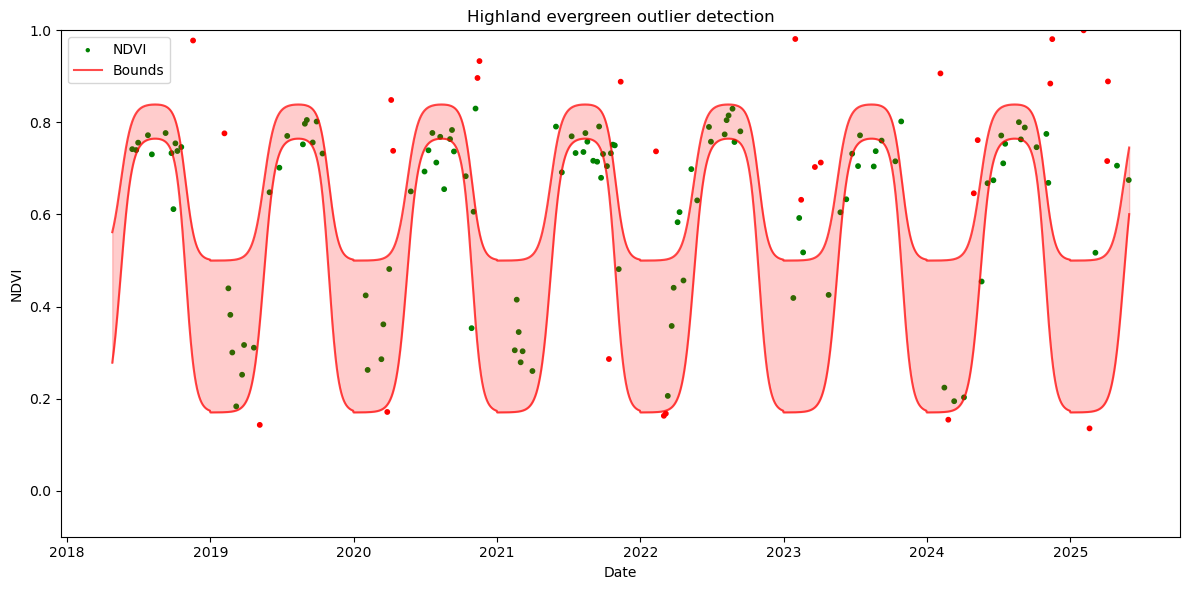

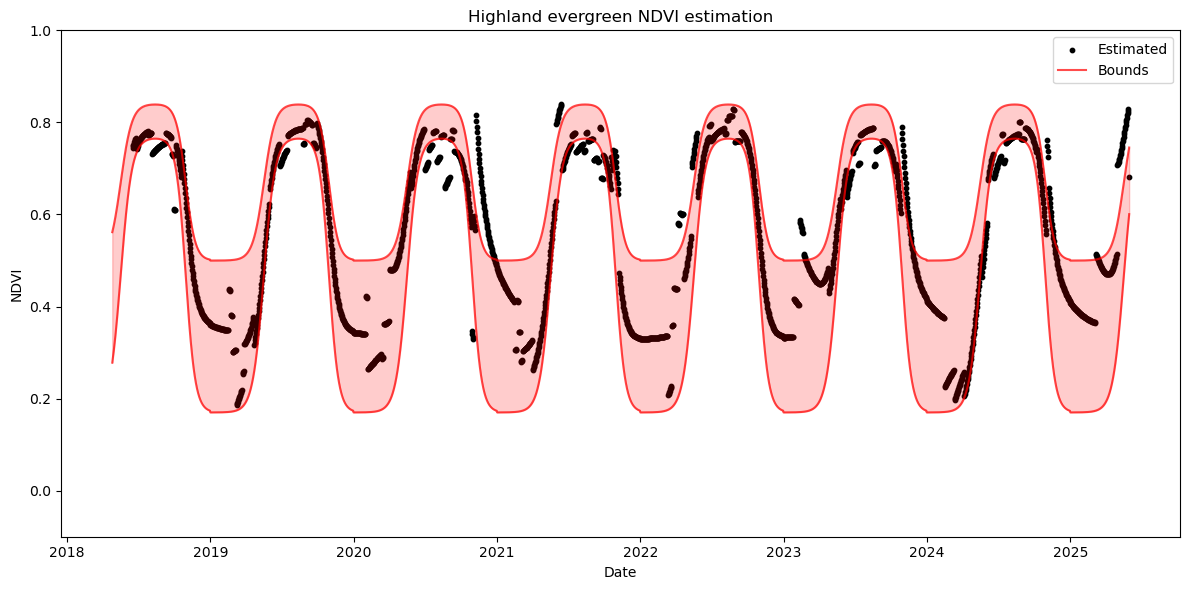

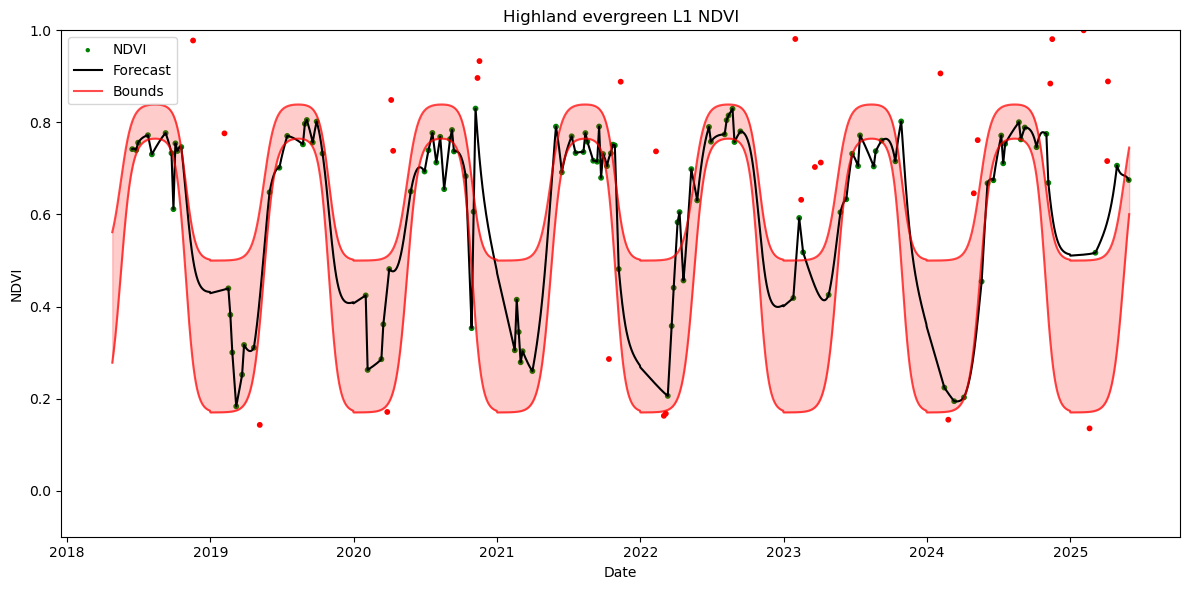

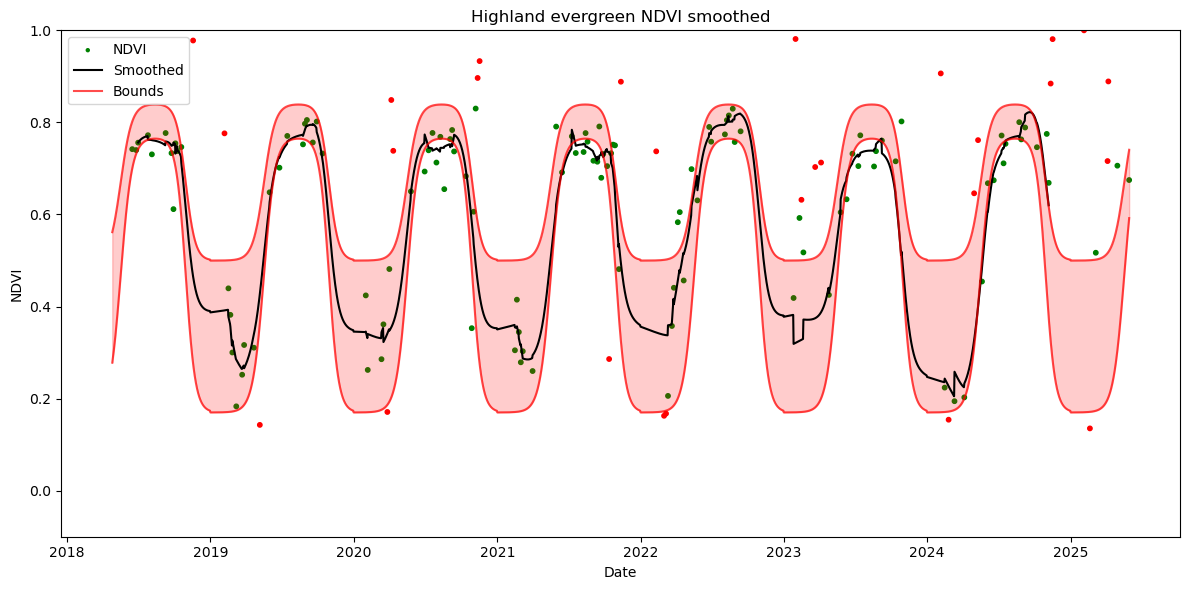

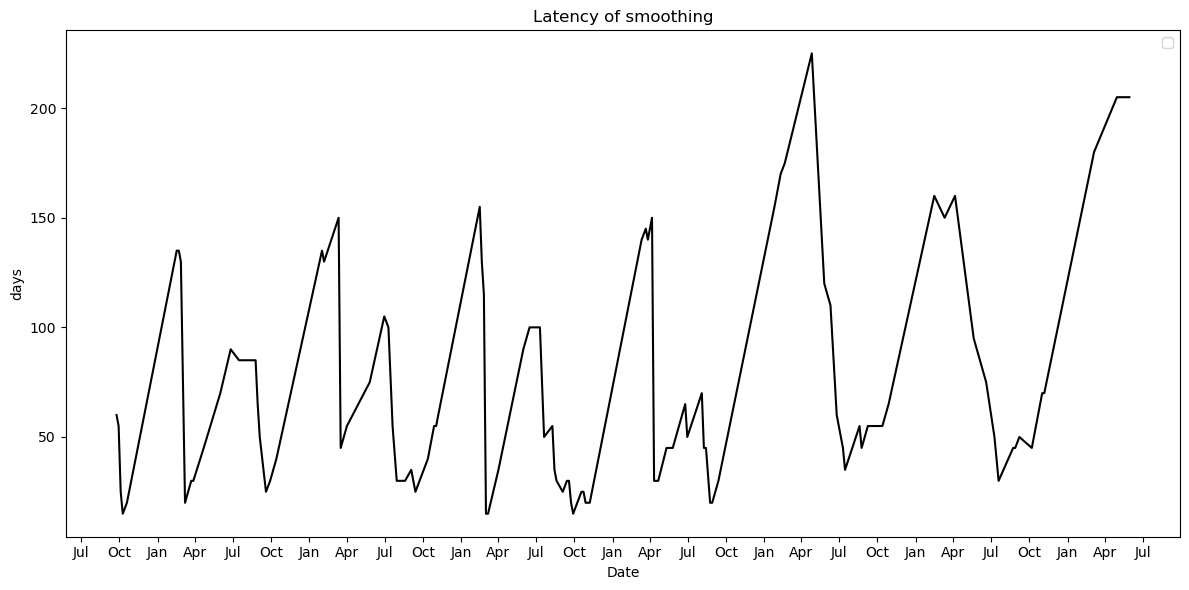

In [9]:
# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

# NDVI as green points
color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Highland evergreen outlier detection")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

#ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.scatter(df_plot.index, df_plot["forecast"], color='black', label='Estimated', s=10)
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Highland evergreen NDVI estimation")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["deltas_L1"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Forecast')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Highland evergreen L1 NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed

# Crop df_plot to that date
df_plot = df[(df.index >= "2018-04-20") & (df.index <=  df[df["outlier"] == False].index.max())]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Smoothed')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Highland evergreen NDVI smoothed")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots(figsize=(12, 6))

# Forecast as black points
ax.plot(current_date_latency, latency, color="black")

# Format x-axis to show ticks every 3 months with month names only
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Latency of smoothing")
ax.set_xlabel("Date")
ax.set_ylabel("days")
ax.legend()
plt.tight_layout()
plt.show()



In [10]:
# data loading and raster initialization
# ----- Config -----
zarr_path = "../pixel_biomes_2.zarr/ndvi"

z = zarr.open(zarr_path, mode="r")

# fitting and smoothing
# ----- seasonal cycle fitting -----
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")
ndvi = ds["ndvi"]
dates = ds["dates"]
params_lower = torch.tensor(ds["params_lower"].values)
params_upper = torch.tensor(ds["params_upper"].values)

# convert dates to doy
dates_pd = pd.to_datetime(dates)
df = pd.DataFrame({"date": dates_pd})
df_sorted = df.sort_values(by="date")
dates_sorted = df_sorted["date"].values
dates_pd_sorted = pd.to_datetime(dates_sorted)
doy = dates_pd_sorted.dayofyear.values
doy = torch.tensor(doy, dtype=torch.float32)
T_SCALE = 1.0 / 365.0
t = doy.unsqueeze(0).repeat(params_lower.shape[0], 1) * T_SCALE


lower = double_logistic_function(t[[0]], params_lower[[91]]).squeeze().cpu().numpy()
upper = double_logistic_function(t[[0]], params_upper[[91]]).squeeze().cpu().numpy()

median_iqr = upper - (upper - lower) / 2

param_iqr = 1.02
bottom_iqr = 0.2
upper_iqr = 0.8
window_length = 14
polyorder = 2

pixel = 100  # pick one pixel index to check

ndvi_series = z[pixel, :]

# proper sorting

df = pd.DataFrame({
    'date': dates_pd,
    'ndvi': ndvi_series
    })

df_sorted = df.sort_values(by='date')

ndvi_sorted = df_sorted['ndvi'].values

ndvi_gapfilled, outlier_arr, q_hi, q_low, delta_diff, iqr_param, smoothed,valid_outlier, valid_idx, deltas = gapfill_ndvi(ndvi_sorted, lower, upper,forecasting=False,
                                            param_iqr=1.02,bottom_q=0.4,
                                            top_q=0.6,return_quantiles = True, weight_median = 0.5,smoothing_method = "savgol")


y_delta_l , y_delta_h,r_delta_h, r_delta_l  = np.quantile(delta_diff, [0.2,0.8,0.95,0.05])
y_iqr, r_iqr = np.quantile(iqr_param, [0.6, 0.8])

# ----- Config -----
zarr_path = "../pixel_biomes.zarr/ndvi"
z = zarr.open(zarr_path, mode="r")

# load seasonal cycle parameters
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")

# pick one pixel
ndvi = z[pixel, :]  
dates = ds["dates"].values   # numpy datetime64

# clean and normalize NDVI
ndvi = ndvi.astype(float) / 10000.0
ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

# --- 1. Create initial df ---
df_starting = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "ndvi": ndvi
    })

# --- 2. Handle duplicate dates ---
df_starting = (
    df_starting.groupby("date", as_index=False)
    .mean(numeric_only=True)   # average if duplicates exist
    .set_index("date")
)

# --- 3. Reindex to full daily series ---
full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
df = df_starting.reindex(full_index)

# add forecast column for later use
df["forecast"] = np.nan
df["upper"] = np.nan
df["lower"] = np.nan
df["gapfilled"] = np.nan
df["outlier"] = False
df["delta_smoothed"] = np.nan
df["idx"] = np.arange(len(df))
df["deltas_L1"] = np.nan


df.index.name = "date"

# remove data veofre marh 2018
df = df.loc[df.index >= pd.Timestamp("2018-04-25")]

# --- run your function row by row ---
# need an inital condition
last_date =  None #pd.Timestamp("2018-04-25")
last_potential_date =None
deltas_arr = []
dates_delta_arr = []
# this is extra just for the plotting
latency = []
current_date_latency = []

for date in df.index[df.index >= pd.Timestamp("2018-04-26")]:
    last_date, last_potential_date_arr, deltas_arr, dates_delta_arr, latency,  current_date_latency = ndvi_continous_final_2(
        df=df,
        date=date,
        params_lower =  params_lower[[91]],
        params_upper =  params_upper[[91]],
        last_date=last_date,
        deltas_arr = deltas_arr,
        dates_delta_arr = dates_delta_arr,
        last_potential_date = last_potential_date,
        y_delta_l = y_delta_l, 
        y_delta_h = y_delta_h,
        r_delta_h = r_delta_h, 
        r_delta_l = r_delta_l,
        y_iqr= y_iqr, 
        r_iqr = r_iqr,
        tau = 45,
        smoothing_values = 7,
        latency = latency,
        current_date_latency = current_date_latency

    )


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:115: RuntimeWarning: divide by zero encountered in divide
  iqr_param = np.where(valid_ndvi / median_valid < 1, median_valid / valid_ndvi, valid_ndvi / median_valid)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:210: RuntimeWarning: divide by zero encountered in divide
  ratio = np.maximum(valid_ndvi, median_valid) / np.minimum(valid_ndvi, median_valid)
/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr

/tmp/ipykernel_2324571/1141650362.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


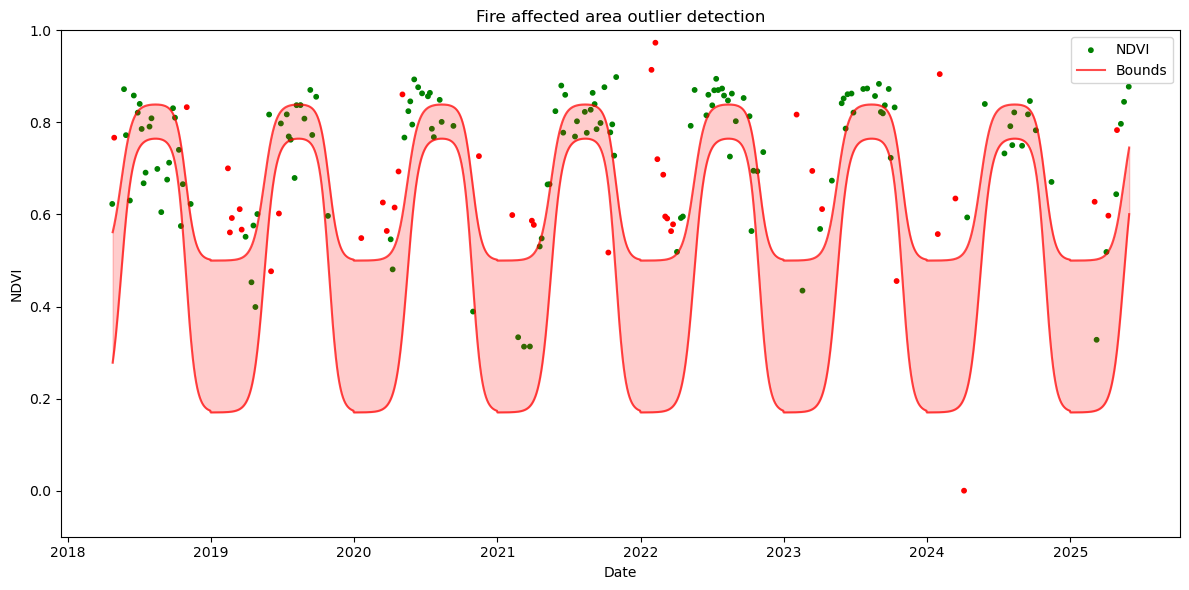

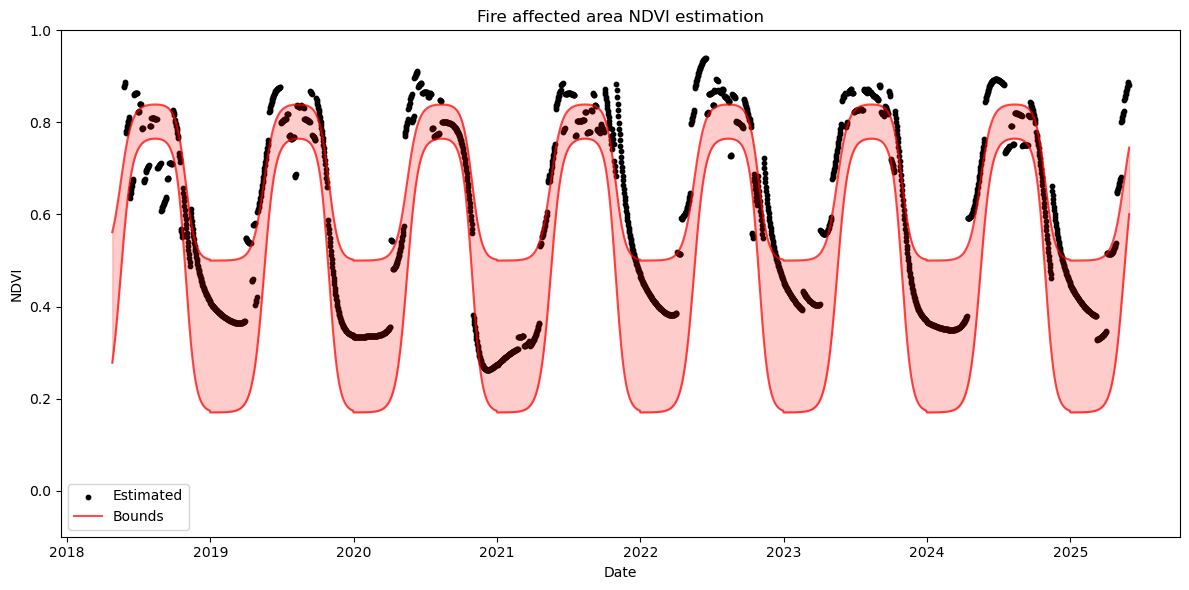

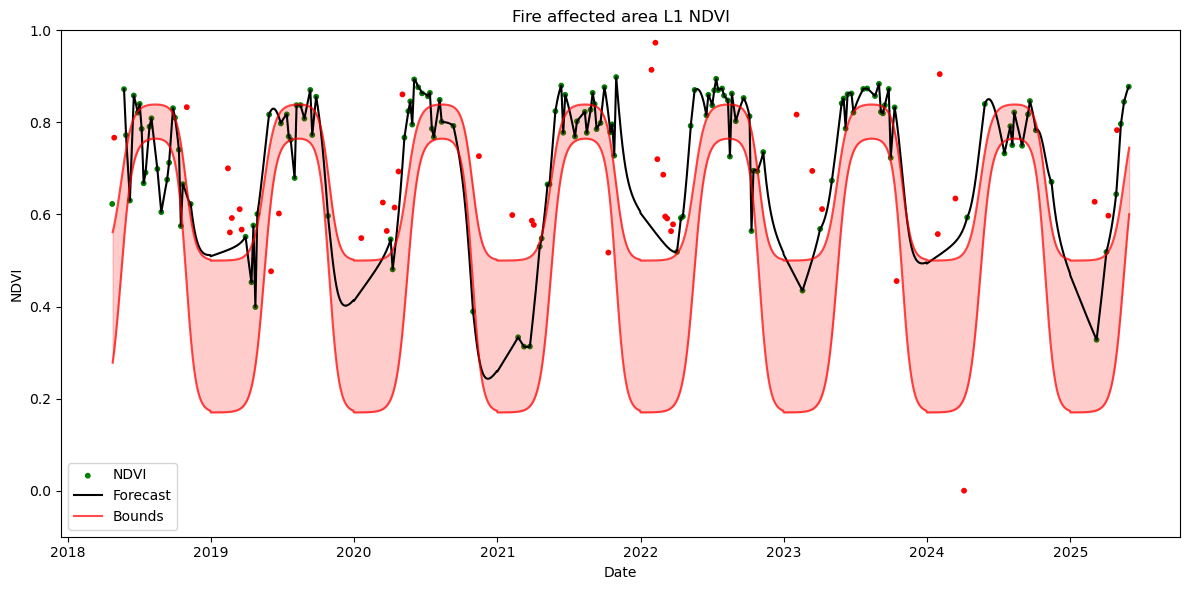

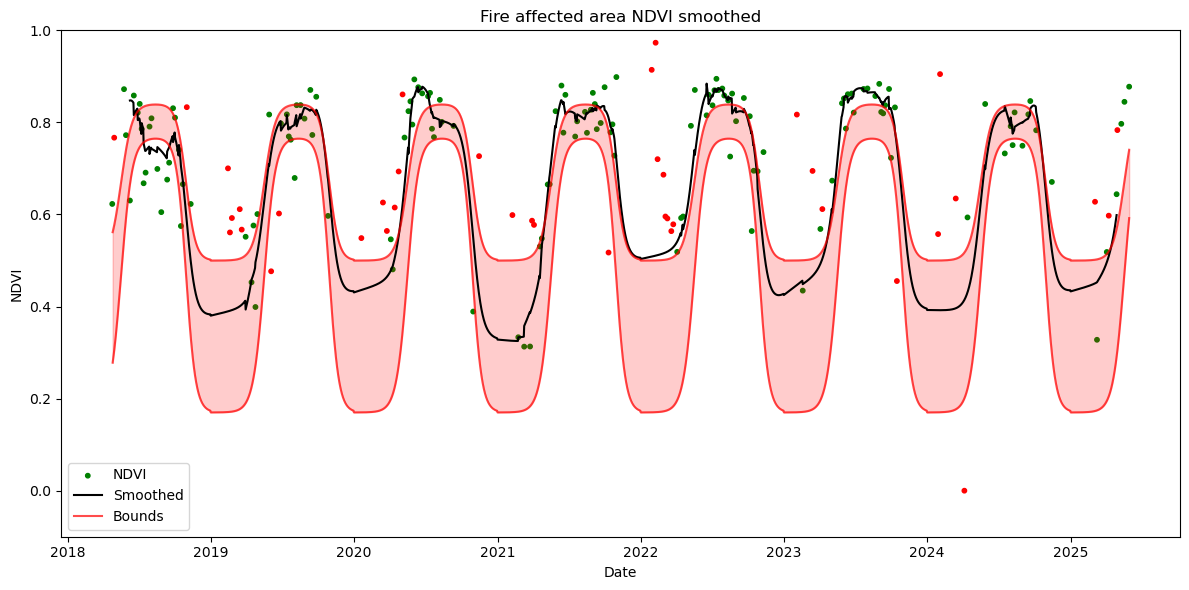

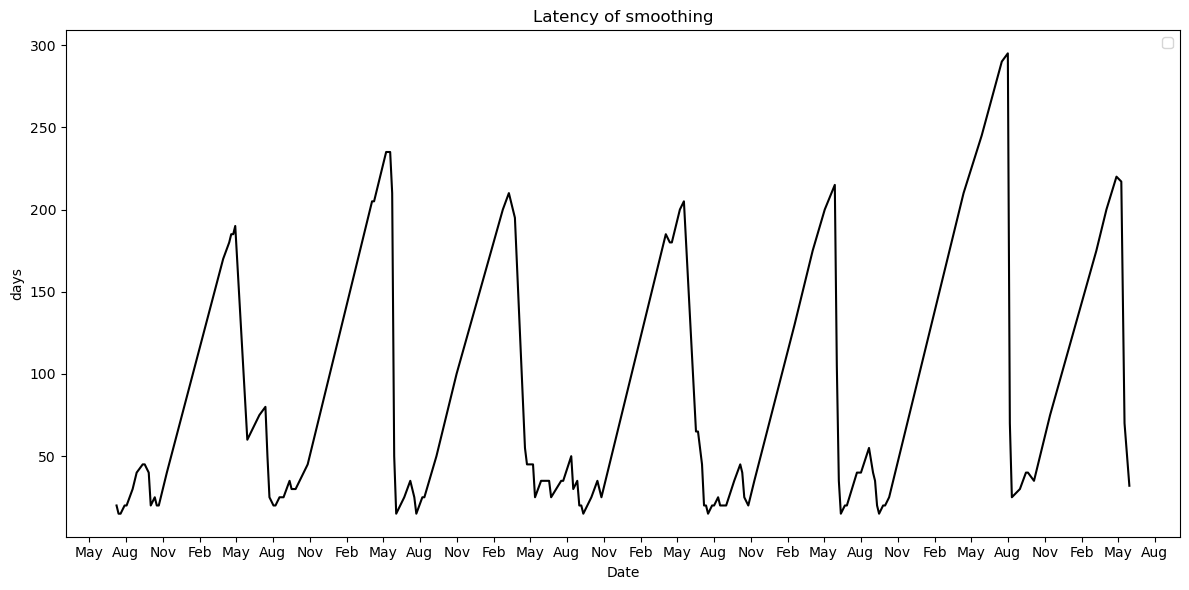

In [11]:
# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

# NDVI as green points
color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Fire affected area outlier detection")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

#ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.scatter(df_plot.index, df_plot["forecast"], color='black', label='Estimated', s=10)
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Fire affected area NDVI estimation")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["deltas_L1"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Forecast')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Fire affected area L1 NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed

# Crop df_plot to that date
df_plot = df[(df.index >= "2018-04-20") & (df.index <=  df[df["outlier"] == False].index.max())]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Smoothed')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Fire affected area NDVI smoothed")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots(figsize=(12, 6))

# Forecast as black points
ax.plot(current_date_latency, latency, color="black")

# Format x-axis to show ticks every 3 months with month names only
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Latency of smoothing")
ax.set_xlabel("Date")
ax.set_ylabel("days")
ax.legend()
plt.tight_layout()
plt.show()



In [12]:
# data loading and raster initialization
# ----- Config -----
zarr_path = "../pixel_biomes_2.zarr/ndvi"

z = zarr.open(zarr_path, mode="r")

# fitting and smoothing
# ----- seasonal cycle fitting -----
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")
ndvi = ds["ndvi"]
dates = ds["dates"]
params_lower = torch.tensor(ds["params_lower"].values)
params_upper = torch.tensor(ds["params_upper"].values)

# convert dates to doy
dates_pd = pd.to_datetime(dates)
df = pd.DataFrame({"date": dates_pd})
df_sorted = df.sort_values(by="date")
dates_sorted = df_sorted["date"].values
dates_pd_sorted = pd.to_datetime(dates_sorted)
doy = dates_pd_sorted.dayofyear.values
doy = torch.tensor(doy, dtype=torch.float32)
T_SCALE = 1.0 / 365.0
t = doy.unsqueeze(0).repeat(params_lower.shape[0], 1) * T_SCALE


lower = double_logistic_function(t[[0]], params_lower[[91]]).squeeze().cpu().numpy()
upper = double_logistic_function(t[[0]], params_upper[[91]]).squeeze().cpu().numpy()

median_iqr = upper - (upper - lower) / 2

param_iqr = 1.02
bottom_iqr = 0.2
upper_iqr = 0.8
window_length = 14
polyorder = 2

pixel = 140  # pick one pixel index to check

ndvi_series = z[pixel, :]

# proper sorting

df = pd.DataFrame({
    'date': dates_pd,
    'ndvi': ndvi_series
    })

df_sorted = df.sort_values(by='date')

ndvi_sorted = df_sorted['ndvi'].values

ndvi_gapfilled, outlier_arr, q_hi, q_low, delta_diff, iqr_param, smoothed,valid_outlier, valid_idx, deltas = gapfill_ndvi(ndvi_sorted, lower, upper,forecasting=False,
                                            param_iqr=1.02,bottom_q=0.4,
                                            top_q=0.6,return_quantiles = True, weight_median = 0.5,smoothing_method = "savgol")


y_delta_l , y_delta_h,r_delta_h, r_delta_l  = np.quantile(delta_diff, [0.2,0.8,0.95,0.05])
y_iqr, r_iqr = np.quantile(iqr_param, [0.6, 0.8])

# ----- Config -----
zarr_path = "../pixel_biomes.zarr/ndvi"
z = zarr.open(zarr_path, mode="r")

# load seasonal cycle parameters
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")

# pick one pixel
ndvi = z[pixel, :]  
dates = ds["dates"].values   # numpy datetime64

# clean and normalize NDVI
ndvi = ndvi.astype(float) / 10000.0
ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

# --- 1. Create initial df ---
df_starting = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "ndvi": ndvi
    })

# --- 2. Handle duplicate dates ---
df_starting = (
    df_starting.groupby("date", as_index=False)
    .mean(numeric_only=True)   # average if duplicates exist
    .set_index("date")
)

# --- 3. Reindex to full daily series ---
full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
df = df_starting.reindex(full_index)

# add forecast column for later use
df["forecast"] = np.nan
df["upper"] = np.nan
df["lower"] = np.nan
df["gapfilled"] = np.nan
df["outlier"] = False
df["delta_smoothed"] = np.nan
df["idx"] = np.arange(len(df))
df["deltas_L1"] = np.nan


df.index.name = "date"

# remove data veofre marh 2018
df = df.loc[df.index >= pd.Timestamp("2018-04-25")]

# --- run your function row by row ---
# need an inital condition
last_date =  None #pd.Timestamp("2018-04-25")
last_potential_date =None
deltas_arr = []
dates_delta_arr = []
# this is extra just for the plotting
latency = []
current_date_latency = []

for date in df.index[df.index >= pd.Timestamp("2018-04-26")]:
    last_date, last_potential_date_arr, deltas_arr, dates_delta_arr, latency,  current_date_latency = ndvi_continous_final_2(
        df=df,
        date=date,
        params_lower =  params_lower[[91]],
        params_upper =  params_upper[[91]],
        last_date=last_date,
        deltas_arr = deltas_arr,
        dates_delta_arr = dates_delta_arr,
        last_potential_date = last_potential_date,
        y_delta_l = y_delta_l, 
        y_delta_h = y_delta_h,
        r_delta_h = r_delta_h, 
        r_delta_l = r_delta_l,
        y_iqr= y_iqr, 
        r_iqr = r_iqr,
        tau = 45,
        smoothing_values = 7,
        latency = latency,
        current_date_latency = current_date_latency

    )


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:115: RuntimeWarning: divide by zero encountered in divide
  iqr_param = np.where(valid_ndvi / median_valid < 1, median_valid / valid_ndvi, valid_ndvi / median_valid)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:210: RuntimeWarning: divide by zero encountered in divide
  ratio = np.maximum(valid_ndvi, median_valid) / np.minimum(valid_ndvi, median_valid)
/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr

/tmp/ipykernel_2324571/3142717353.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


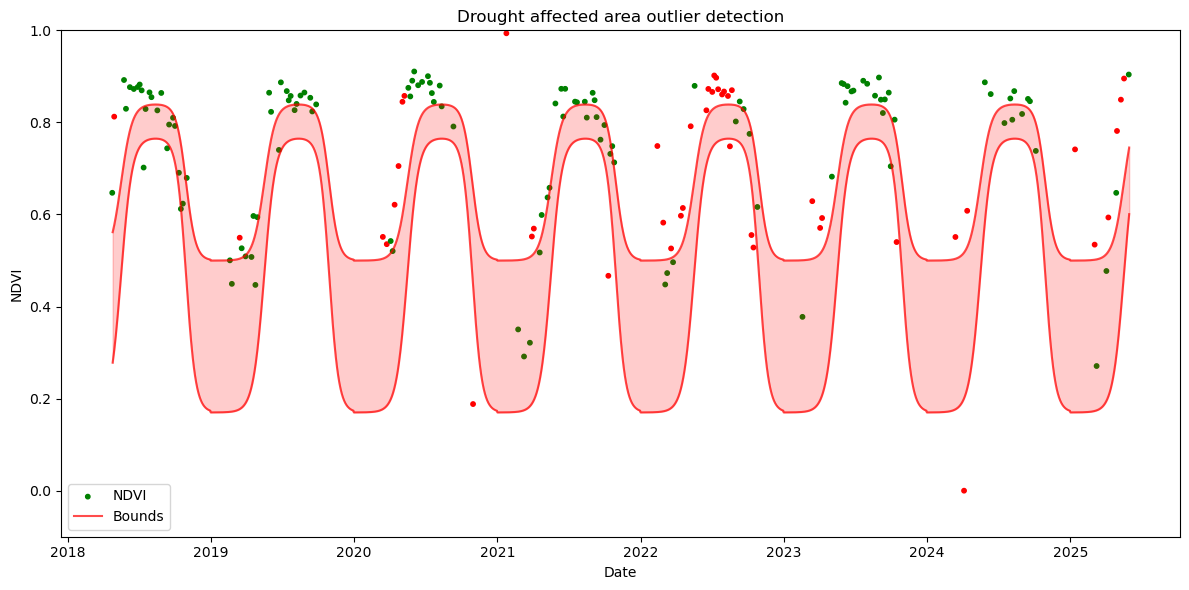

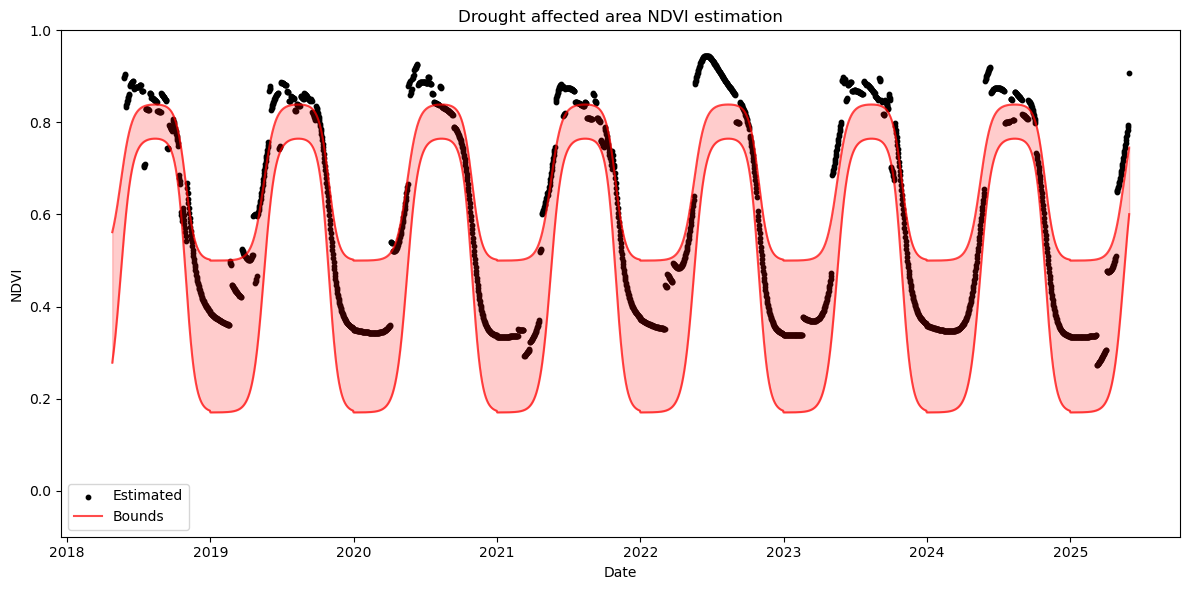

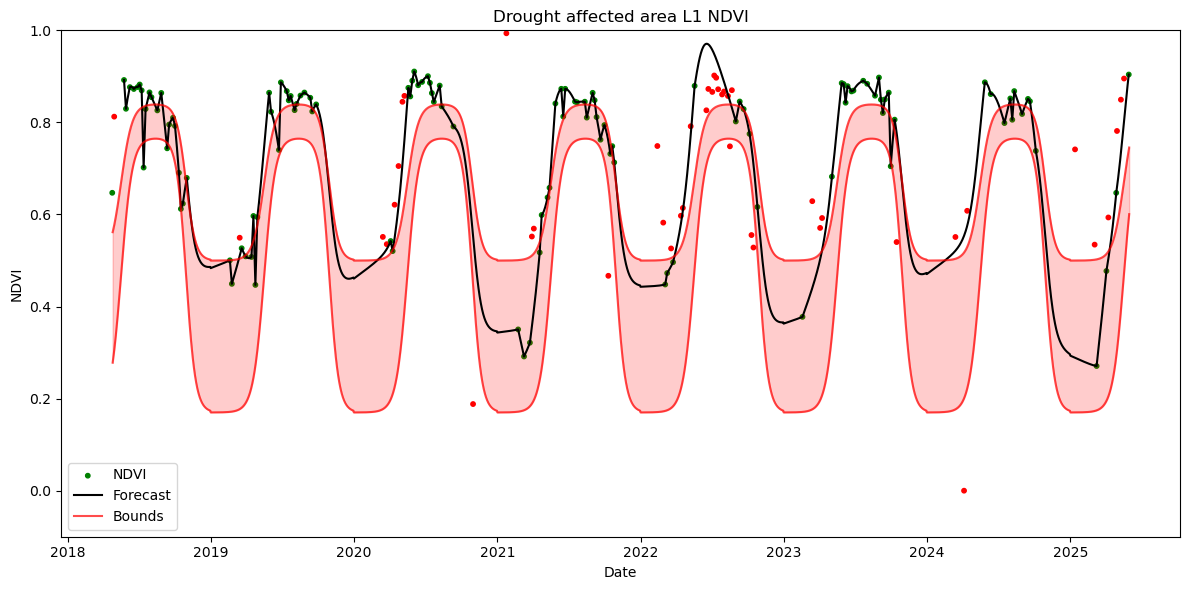

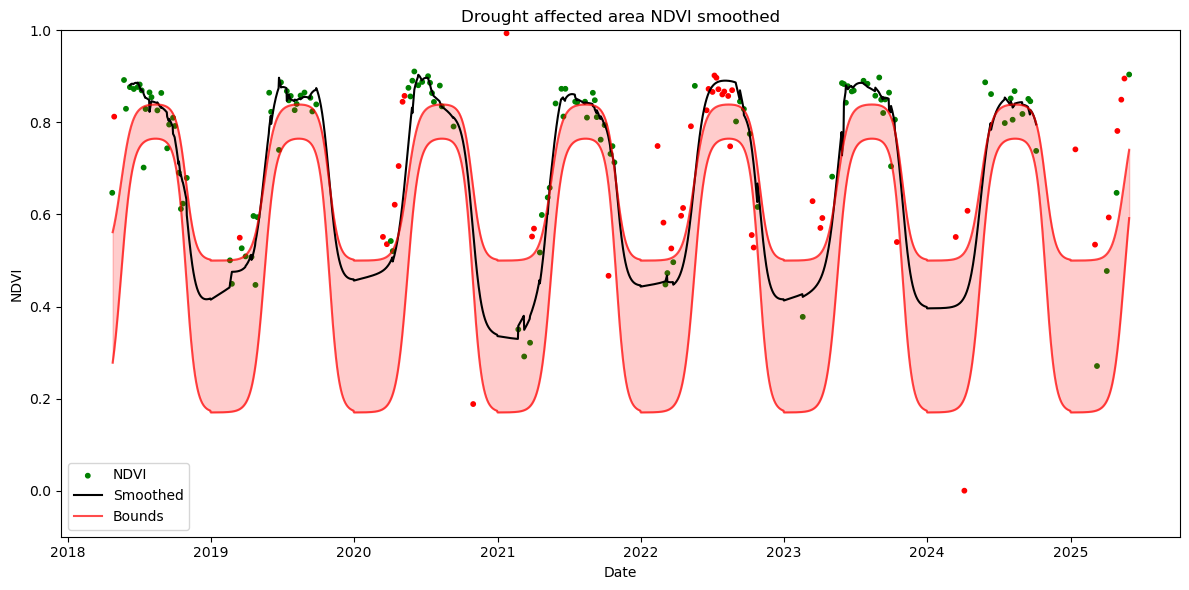

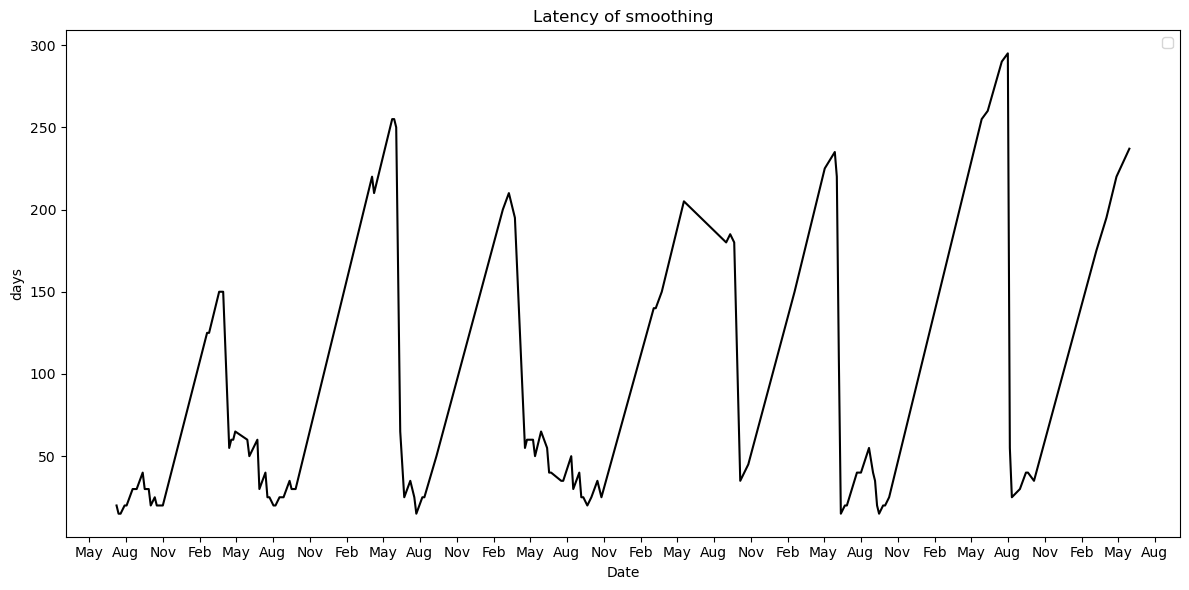

In [13]:
# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

# NDVI as green points
color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Drought affected area outlier detection")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

#ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.scatter(df_plot.index, df_plot["forecast"], color='black', label='Estimated', s=10)
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Drought affected area NDVI estimation")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["deltas_L1"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Forecast')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Drought affected area L1 NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed

# Crop df_plot to that date
df_plot = df[(df.index >= "2018-04-20") & (df.index <=  df[df["outlier"] == False].index.max())]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Smoothed')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Drought affected area NDVI smoothed")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots(figsize=(12, 6))

# Forecast as black points
ax.plot(current_date_latency, latency, color="black")

# Format x-axis to show ticks every 3 months with month names only
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Latency of smoothing")
ax.set_xlabel("Date")
ax.set_ylabel("days")
ax.legend()
plt.tight_layout()
plt.show()



In [14]:
# data loading and raster initialization
# ----- Config -----
zarr_path = "../pixel_biomes_2.zarr/ndvi"

z = zarr.open(zarr_path, mode="r")

# fitting and smoothing
# ----- seasonal cycle fitting -----
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")
ndvi = ds["ndvi"]
dates = ds["dates"]
params_lower = torch.tensor(ds["params_lower"].values)
params_upper = torch.tensor(ds["params_upper"].values)

# convert dates to doy
dates_pd = pd.to_datetime(dates)
df = pd.DataFrame({"date": dates_pd})
df_sorted = df.sort_values(by="date")
dates_sorted = df_sorted["date"].values
dates_pd_sorted = pd.to_datetime(dates_sorted)
doy = dates_pd_sorted.dayofyear.values
doy = torch.tensor(doy, dtype=torch.float32)
T_SCALE = 1.0 / 365.0
t = doy.unsqueeze(0).repeat(params_lower.shape[0], 1) * T_SCALE


lower = double_logistic_function(t[[0]], params_lower[[91]]).squeeze().cpu().numpy()
upper = double_logistic_function(t[[0]], params_upper[[91]]).squeeze().cpu().numpy()

median_iqr = upper - (upper - lower) / 2

param_iqr = 1.02
bottom_iqr = 0.2
upper_iqr = 0.8
window_length = 14
polyorder = 2

pixel = 160  # pick one pixel index to check

ndvi_series = z[pixel, :]

# proper sorting

df = pd.DataFrame({
    'date': dates_pd,
    'ndvi': ndvi_series
    })

df_sorted = df.sort_values(by='date')

ndvi_sorted = df_sorted['ndvi'].values

ndvi_gapfilled, outlier_arr, q_hi, q_low, delta_diff, iqr_param, smoothed,valid_outlier, valid_idx, deltas = gapfill_ndvi(ndvi_sorted, lower, upper,forecasting=False,
                                            param_iqr=1.02,bottom_q=0.4,
                                            top_q=0.6,return_quantiles = True, weight_median = 0.5,smoothing_method = "savgol")


y_delta_l , y_delta_h,r_delta_h, r_delta_l  = np.quantile(delta_diff, [0.2,0.8,0.95,0.05])
y_iqr, r_iqr = np.quantile(iqr_param, [0.6, 0.8])

# ----- Config -----
zarr_path = "../pixel_biomes.zarr/ndvi"
z = zarr.open(zarr_path, mode="r")

# load seasonal cycle parameters
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")

# pick one pixel
ndvi = z[pixel, :]  
dates = ds["dates"].values   # numpy datetime64

# clean and normalize NDVI
ndvi = ndvi.astype(float) / 10000.0
ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

# --- 1. Create initial df ---
df_starting = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "ndvi": ndvi
    })

# --- 2. Handle duplicate dates ---
df_starting = (
    df_starting.groupby("date", as_index=False)
    .mean(numeric_only=True)   # average if duplicates exist
    .set_index("date")
)

# --- 3. Reindex to full daily series ---
full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
df = df_starting.reindex(full_index)

# add forecast column for later use
df["forecast"] = np.nan
df["upper"] = np.nan
df["lower"] = np.nan
df["gapfilled"] = np.nan
df["outlier"] = False
df["delta_smoothed"] = np.nan
df["idx"] = np.arange(len(df))
df["deltas_L1"] = np.nan


df.index.name = "date"

# remove data veofre marh 2018
df = df.loc[df.index >= pd.Timestamp("2018-04-25")]

# --- run your function row by row ---
# need an inital condition
last_date =  None #pd.Timestamp("2018-04-25")
last_potential_date =None
deltas_arr = []
dates_delta_arr = []
# this is extra just for the plotting
latency = []
current_date_latency = []

for date in df.index[df.index >= pd.Timestamp("2018-04-26")]:
    last_date, last_potential_date_arr, deltas_arr, dates_delta_arr, latency,  current_date_latency = ndvi_continous_final_2(
        df=df,
        date=date,
        params_lower =  params_lower[[91]],
        params_upper =  params_upper[[91]],
        last_date=last_date,
        deltas_arr = deltas_arr,
        dates_delta_arr = dates_delta_arr,
        last_potential_date = last_potential_date,
        y_delta_l = y_delta_l, 
        y_delta_h = y_delta_h,
        r_delta_h = r_delta_h, 
        r_delta_l = r_delta_l,
        y_iqr= y_iqr, 
        r_iqr = r_iqr,
        tau = 45,
        smoothing_values = 7,
        latency = latency,
        current_date_latency = current_date_latency

    )


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:115: RuntimeWarning: divide by zero encountered in divide
  iqr_param = np.where(valid_ndvi / median_valid < 1, median_valid / valid_ndvi, valid_ndvi / median_valid)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:210: RuntimeWarning: divide by zero encountered in divide
  ratio = np.maximum(valid_ndvi, median_valid) / np.minimum(valid_ndvi, median_valid)
/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr

/tmp/ipykernel_2324571/3142717353.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


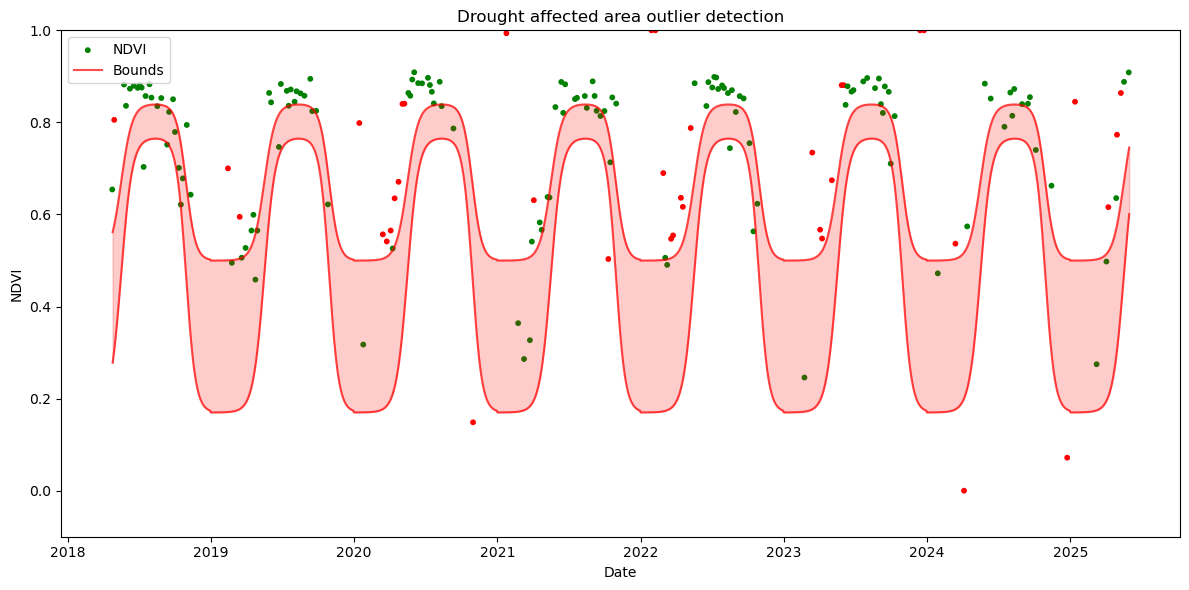

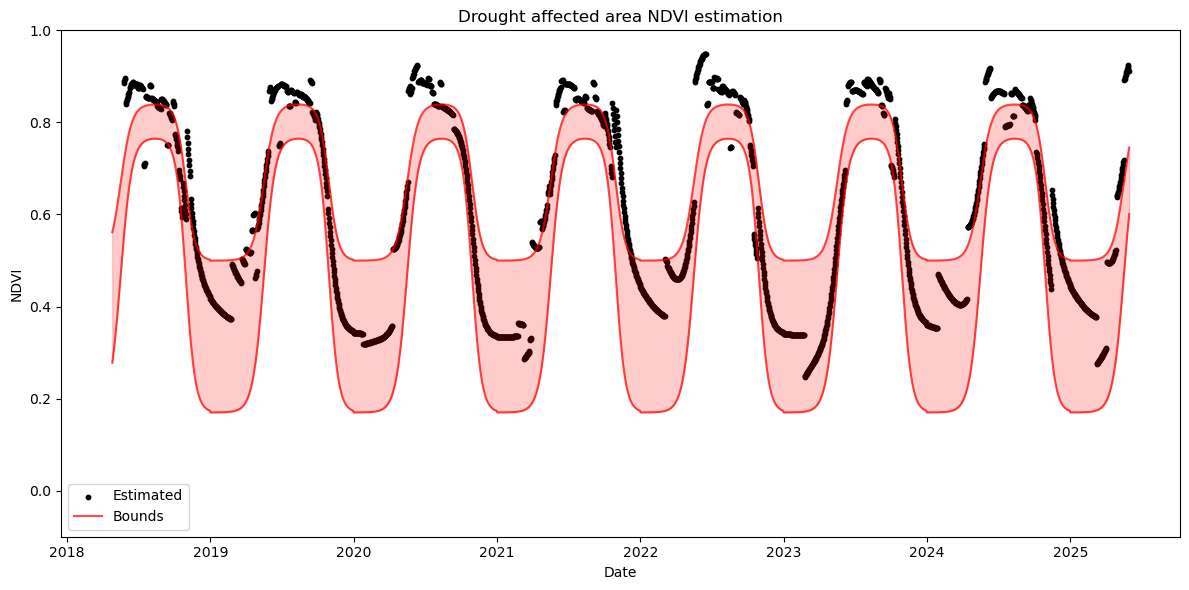

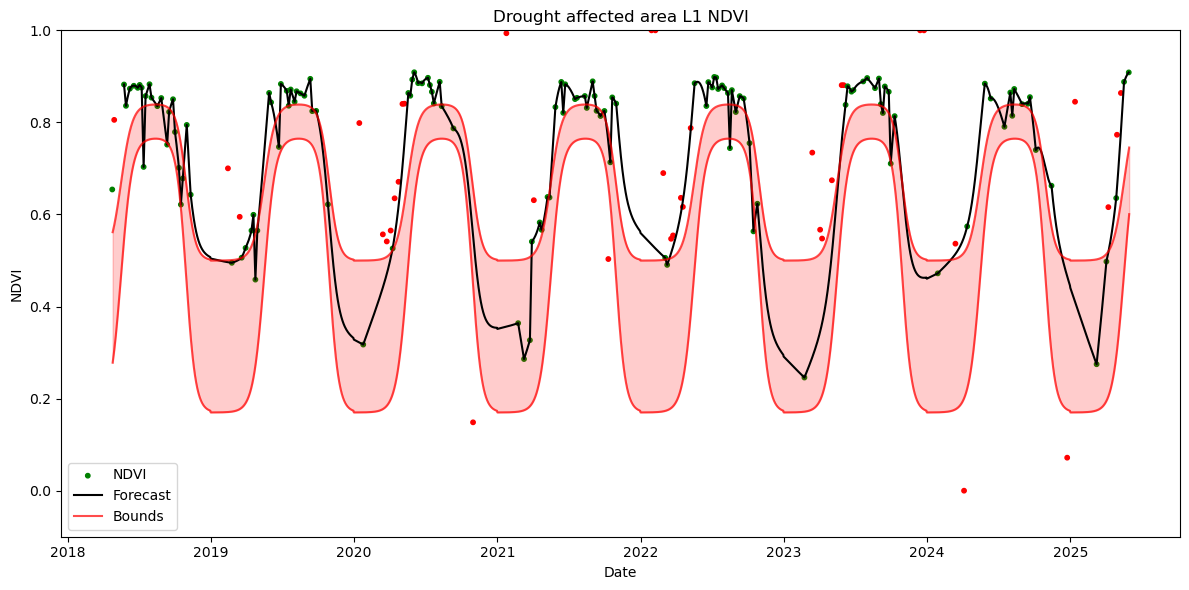

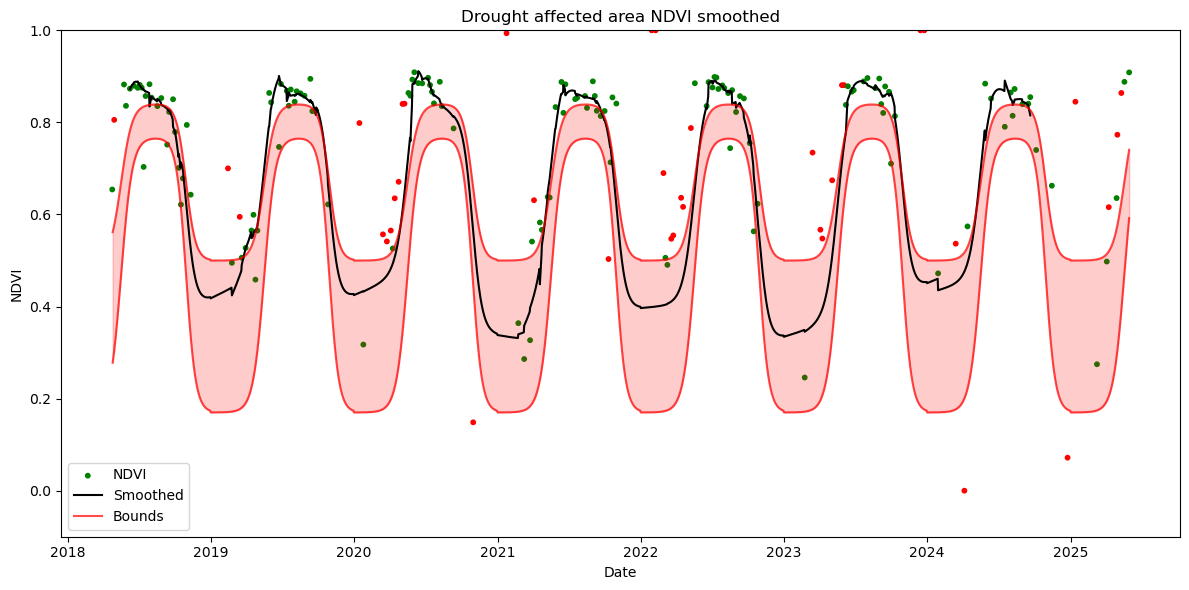

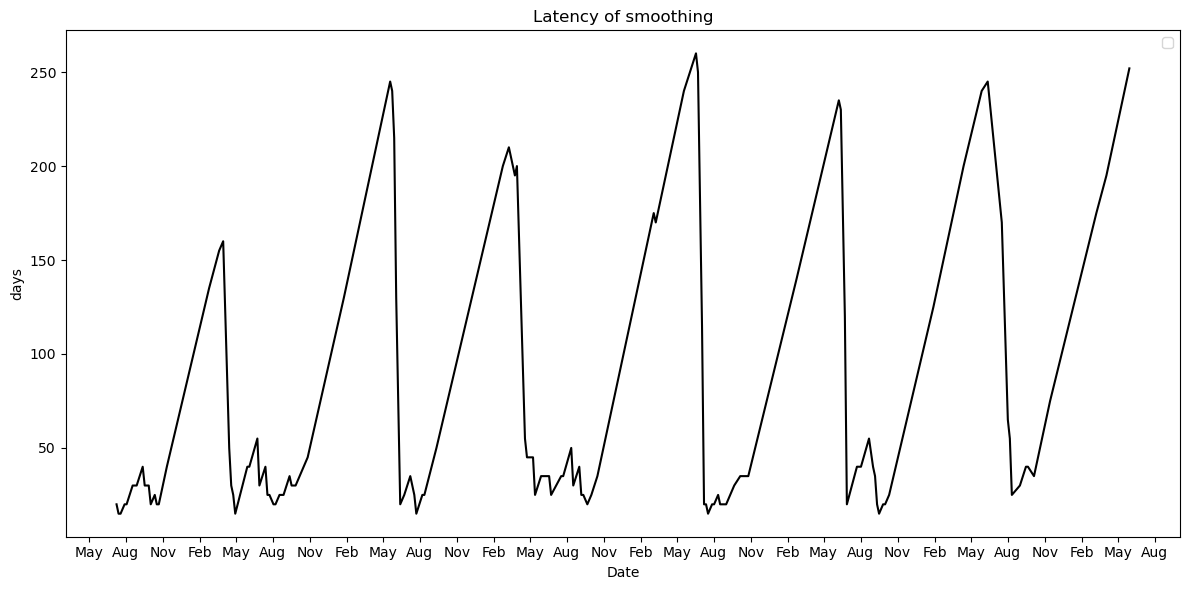

In [15]:
# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

# NDVI as green points
color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Drought affected area outlier detection")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

#ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.scatter(df_plot.index, df_plot["forecast"], color='black', label='Estimated', s=10)
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Drought affected area NDVI estimation")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["deltas_L1"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Forecast')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Drought affected area L1 NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed

# Crop df_plot to that date
df_plot = df[(df.index >= "2018-04-20") & (df.index <=  df[df["outlier"] == False].index.max())]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Smoothed')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Drought affected area NDVI smoothed")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots(figsize=(12, 6))

# Forecast as black points
ax.plot(current_date_latency, latency, color="black")

# Format x-axis to show ticks every 3 months with month names only
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Latency of smoothing")
ax.set_xlabel("Date")
ax.set_ylabel("days")
ax.legend()
plt.tight_layout()
plt.show()



In [16]:
# data loading and raster initialization
# ----- Config -----
zarr_path = "../pixel_biomes_2.zarr/ndvi"

z = zarr.open(zarr_path, mode="r")

# fitting and smoothing
# ----- seasonal cycle fitting -----
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")
ndvi = ds["ndvi"]
dates = ds["dates"]
params_lower = torch.tensor(ds["params_lower"].values)
params_upper = torch.tensor(ds["params_upper"].values)

# convert dates to doy
dates_pd = pd.to_datetime(dates)
df = pd.DataFrame({"date": dates_pd})
df_sorted = df.sort_values(by="date")
dates_sorted = df_sorted["date"].values
dates_pd_sorted = pd.to_datetime(dates_sorted)
doy = dates_pd_sorted.dayofyear.values
doy = torch.tensor(doy, dtype=torch.float32)
T_SCALE = 1.0 / 365.0
t = doy.unsqueeze(0).repeat(params_lower.shape[0], 1) * T_SCALE


lower = double_logistic_function(t[[0]], params_lower[[91]]).squeeze().cpu().numpy()
upper = double_logistic_function(t[[0]], params_upper[[91]]).squeeze().cpu().numpy()

median_iqr = upper - (upper - lower) / 2

param_iqr = 1.02
bottom_iqr = 0.2
upper_iqr = 0.8
window_length = 14
polyorder = 2

pixel = 180  # pick one pixel index to check

ndvi_series = z[pixel, :]

# proper sorting

df = pd.DataFrame({
    'date': dates_pd,
    'ndvi': ndvi_series
    })

df_sorted = df.sort_values(by='date')

ndvi_sorted = df_sorted['ndvi'].values

ndvi_gapfilled, outlier_arr, q_hi, q_low, delta_diff, iqr_param, smoothed,valid_outlier, valid_idx, deltas = gapfill_ndvi(ndvi_sorted, lower, upper,forecasting=False,
                                            param_iqr=1.02,bottom_q=0.4,
                                            top_q=0.6,return_quantiles = True, weight_median = 0.5,smoothing_method = "savgol")


y_delta_l , y_delta_h,r_delta_h, r_delta_l  = np.quantile(delta_diff, [0.2,0.8,0.95,0.05])
y_iqr, r_iqr = np.quantile(iqr_param, [0.6, 0.8])

# ----- Config -----
zarr_path = "../pixel_biomes.zarr/ndvi"
z = zarr.open(zarr_path, mode="r")

# load seasonal cycle parameters
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")

# pick one pixel
ndvi = z[pixel, :]  
dates = ds["dates"].values   # numpy datetime64

# clean and normalize NDVI
ndvi = ndvi.astype(float) / 10000.0
ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

# --- 1. Create initial df ---
df_starting = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "ndvi": ndvi
    })

# --- 2. Handle duplicate dates ---
df_starting = (
    df_starting.groupby("date", as_index=False)
    .mean(numeric_only=True)   # average if duplicates exist
    .set_index("date")
)

# --- 3. Reindex to full daily series ---
full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
df = df_starting.reindex(full_index)

# add forecast column for later use
df["forecast"] = np.nan
df["upper"] = np.nan
df["lower"] = np.nan
df["gapfilled"] = np.nan
df["outlier"] = False
df["delta_smoothed"] = np.nan
df["idx"] = np.arange(len(df))
df["deltas_L1"] = np.nan


df.index.name = "date"

# remove data veofre marh 2018
df = df.loc[df.index >= pd.Timestamp("2018-04-25")]

# --- run your function row by row ---
# need an inital condition
last_date =  None #pd.Timestamp("2018-04-25")
last_potential_date =None
deltas_arr = []
dates_delta_arr = []
# this is extra just for the plotting
latency = []
current_date_latency = []

for date in df.index[df.index >= pd.Timestamp("2018-04-26")]:
    last_date, last_potential_date_arr, deltas_arr, dates_delta_arr, latency,  current_date_latency = ndvi_continous_final_2(
        df=df,
        date=date,
        params_lower =  params_lower[[91]],
        params_upper =  params_upper[[91]],
        last_date=last_date,
        deltas_arr = deltas_arr,
        dates_delta_arr = dates_delta_arr,
        last_potential_date = last_potential_date,
        y_delta_l = y_delta_l, 
        y_delta_h = y_delta_h,
        r_delta_h = r_delta_h, 
        r_delta_l = r_delta_l,
        y_iqr= y_iqr, 
        r_iqr = r_iqr,
        tau = 45,
        smoothing_values = 7,
        latency = latency,
        current_date_latency = current_date_latency

    )


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:115: RuntimeWarning: divide by zero encountered in divide
  iqr_param = np.where(valid_ndvi / median_valid < 1, median_valid / valid_ndvi, valid_ndvi / median_valid)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:210: RuntimeWarning: divide by zero encountered in divide
  ratio = np.maximum(valid_ndvi, median_valid) / np.minimum(valid_ndvi, median_valid)
/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr

/tmp/ipykernel_2324571/1346275626.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


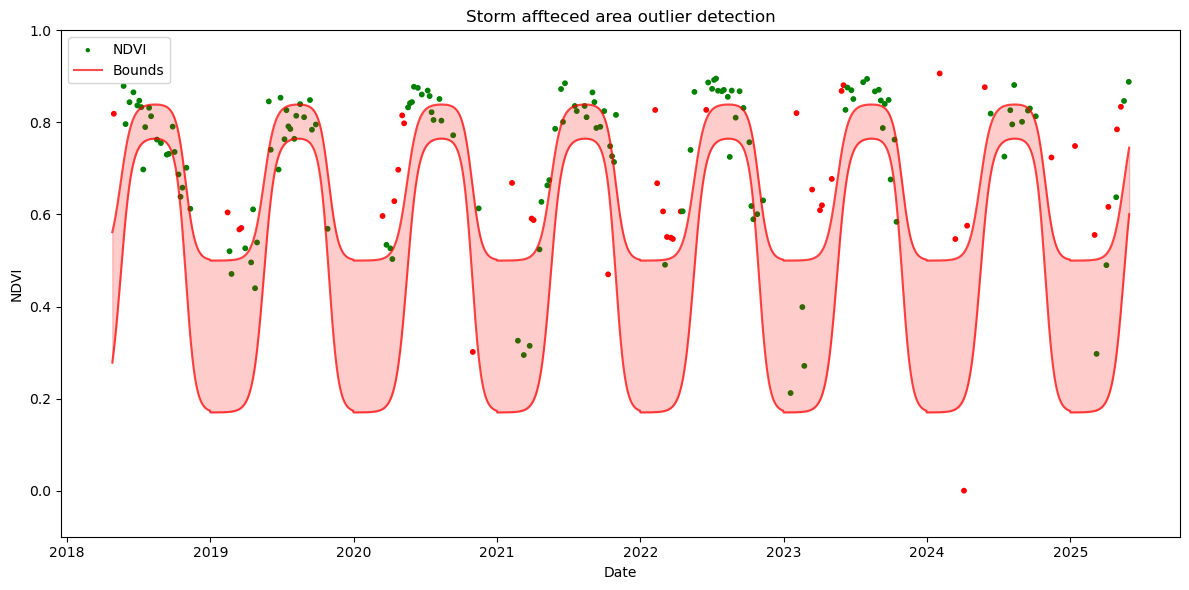

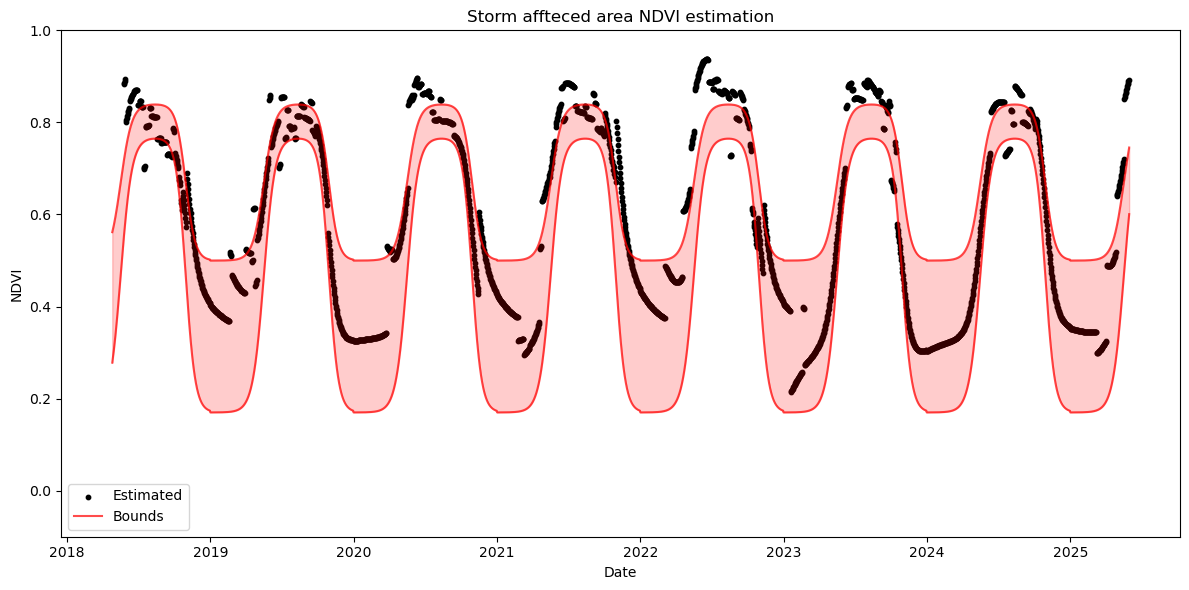

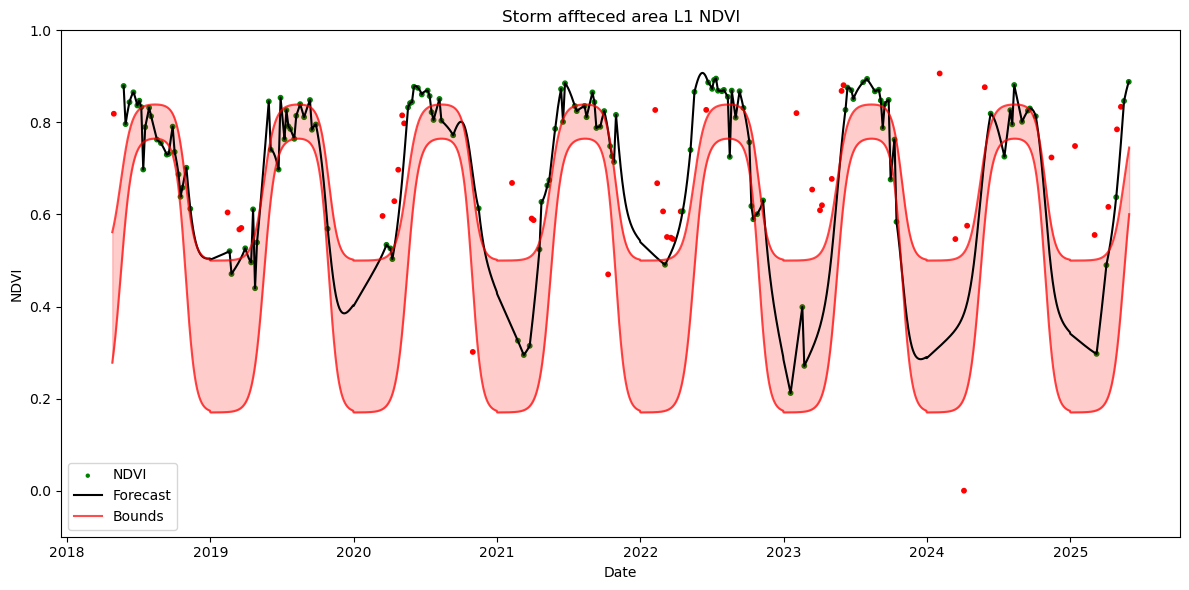

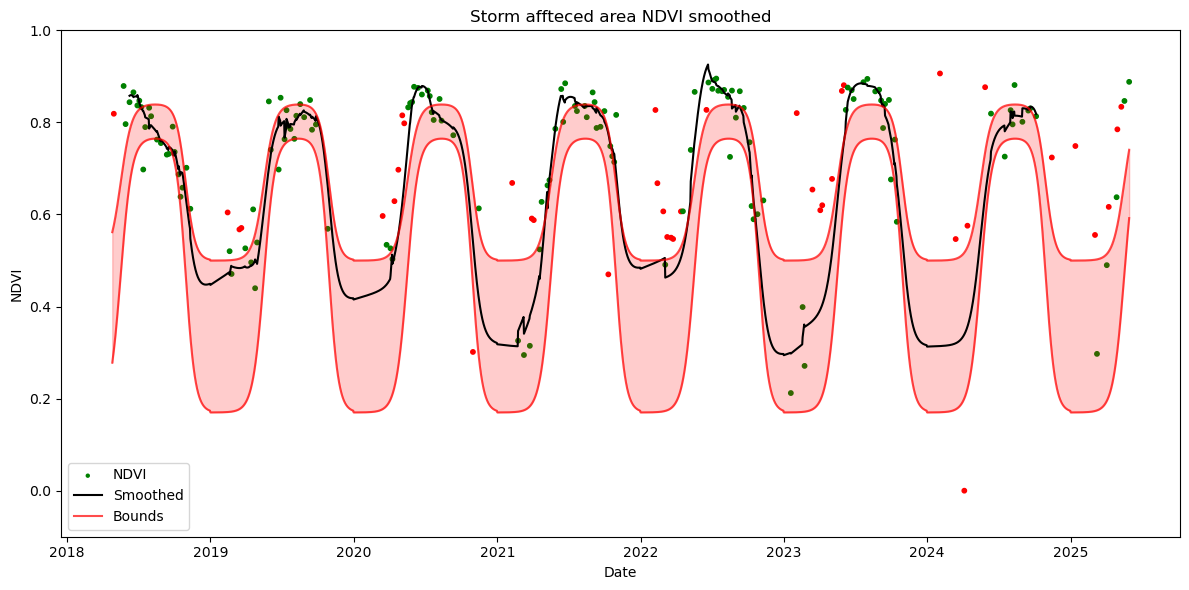

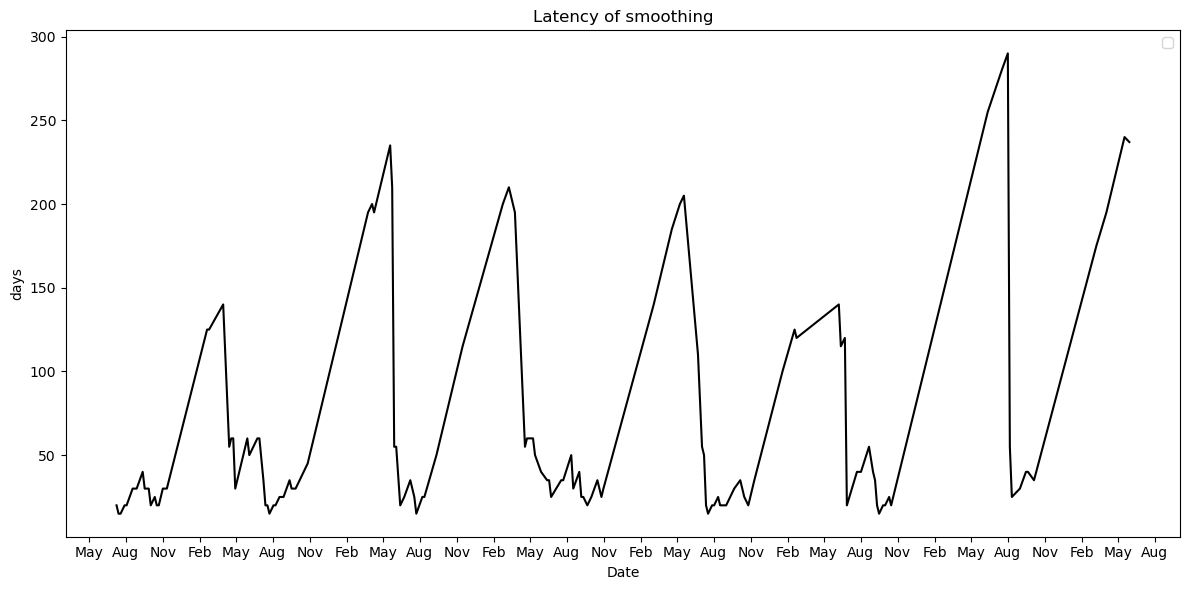

In [17]:
# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

# NDVI as green points
color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Storm affteced area outlier detection")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

#ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.scatter(df_plot.index, df_plot["forecast"], color='black', label='Estimated', s=10)
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Storm affteced area NDVI estimation")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["deltas_L1"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Forecast')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Storm affteced area L1 NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()


# Select a date range if needed

# Crop df_plot to that date
df_plot = df[(df.index >= "2018-04-20") & (df.index <=  df[df["outlier"] == False].index.max())]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Smoothed')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Storm affteced area NDVI smoothed")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots(figsize=(12, 6))

# Forecast as black points
ax.plot(current_date_latency, latency, color="black")

# Format x-axis to show ticks every 3 months with month names only
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Latency of smoothing")
ax.set_xlabel("Date")
ax.set_ylabel("days")
ax.legend()
plt.tight_layout()
plt.show()



## Second half

In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(0, 12)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.suptitle("NDVI Time Series for Pixels 12–24", fontsize=16)
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(12, 24)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.suptitle("NDVI Time Series for Pixels 12–24", fontsize=16)
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(25, 37)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.suptitle("NDVI Time Series for Pixels 12–24", fontsize=16)
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(37, 49)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.suptitle("NDVI Time Series for Pixels 12–24", fontsize=16)
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(50, 62)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.suptitle("NDVI Time Series for Pixels 12–24", fontsize=16)
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(62, 74)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.suptitle("NDVI Time Series for Pixels 12–24", fontsize=16)
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


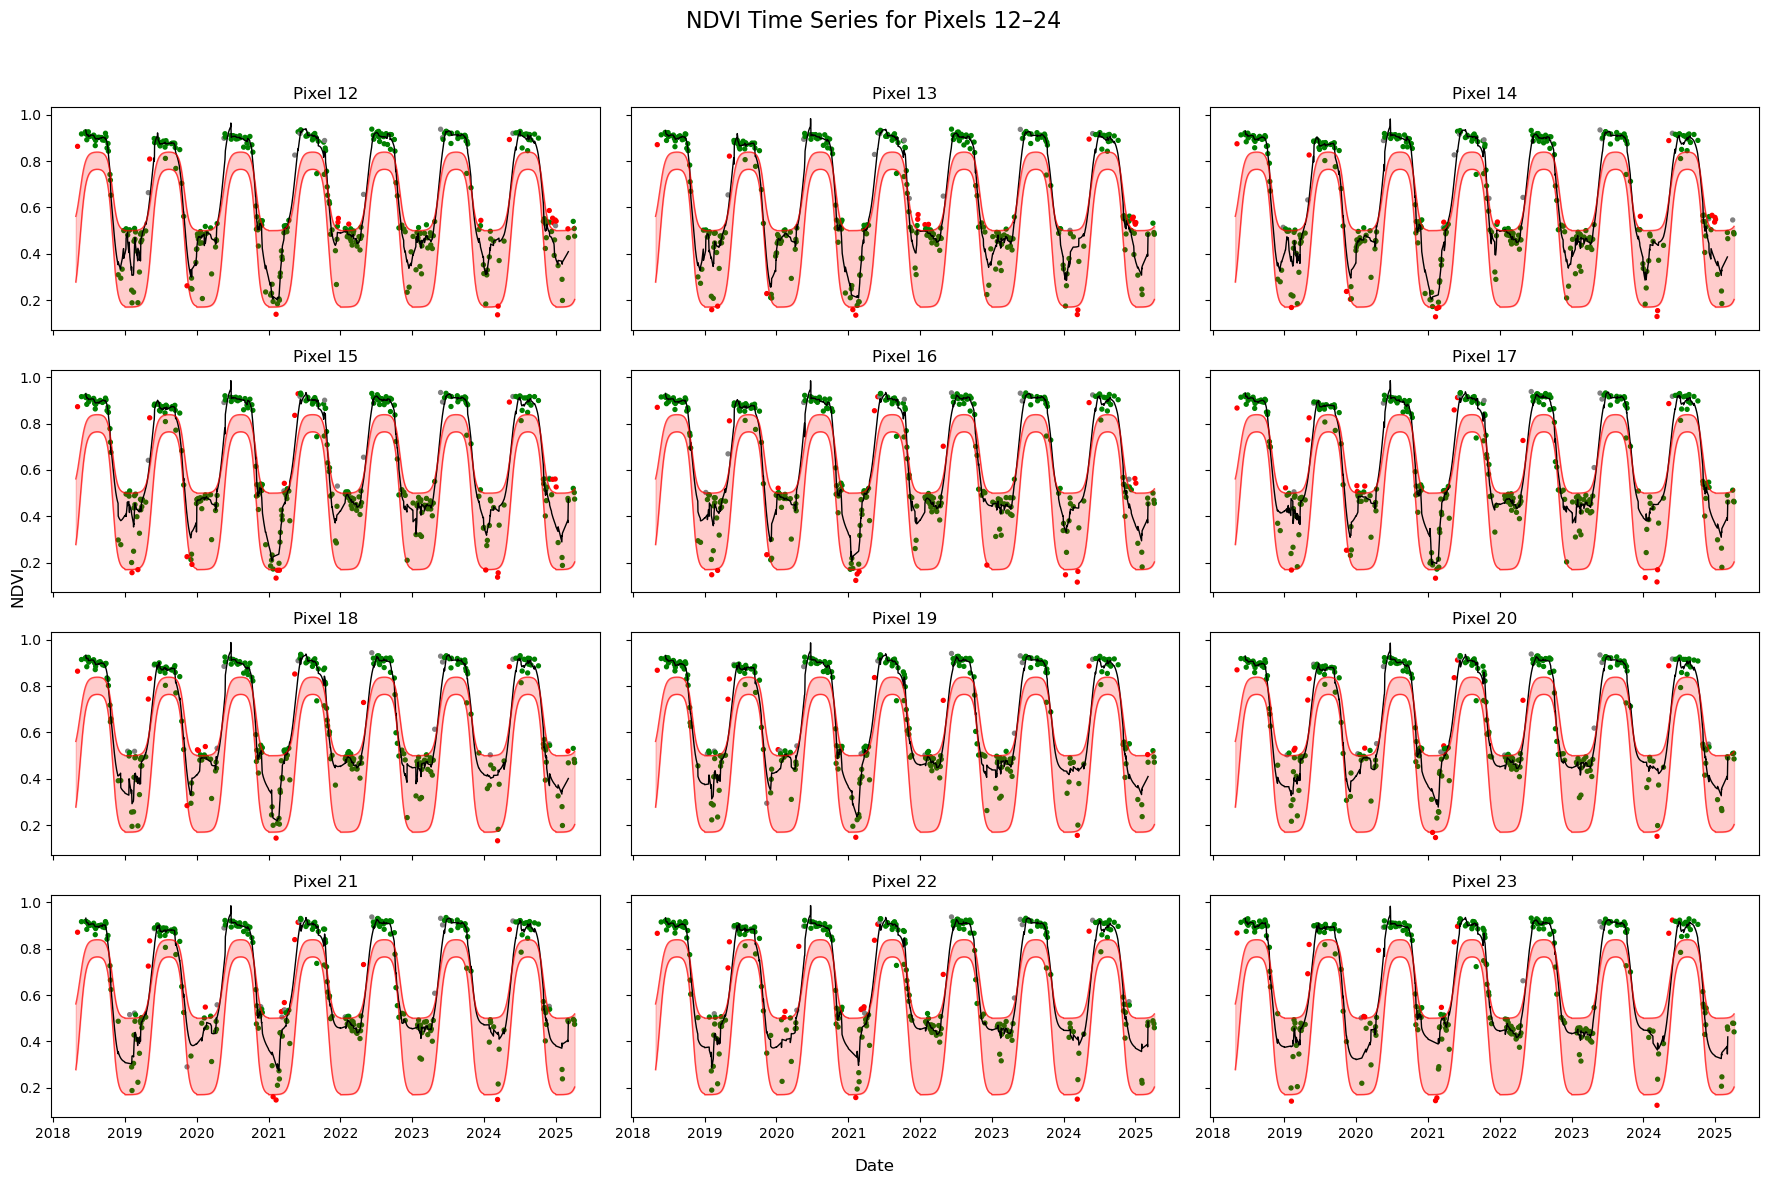

In [ ]:
c

In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(87, 99)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(87, 99)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(100, 112)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(112, 124)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(125, 137)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(137, 149)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(150, 162)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(162, 174)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(175, 187)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# --- loop over pixels 12 to 24 and create a 4x3 figure ---
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, pixel in enumerate(range(187, 199)):
    # --- Load NDVI for this pixel ---
    ndvi = z[pixel, :].astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # --- Build DataFrame for this pixel ---
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": ndvi
    })
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)
        .set_index("date")
    )
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df_pixel = df_starting.reindex(full_index)
    df_pixel.index.name = "date"

    # filter time range (same as your script)
    df_pixel = df_pixel.loc[df_pixel.index >= pd.Timestamp("2018-04-25")]

    # Run your gapfilling / smoothing function for each pixel
    last_date = None
    last_potential_date = None
    deltas_arr, dates_delta_arr, latency, current_date_latency = [], [], [], []
    for date in df_pixel.index[df_pixel.index >= pd.Timestamp("2018-04-26")]:
        last_date, last_potential_date, deltas_arr, dates_delta_arr, latency, current_date_latency = ndvi_continous_final_2(
            df=df_pixel,
            date=date,
            params_lower=params_lower[[91]],  # update as needed
            params_upper=params_upper[[91]],
            last_date=last_date,
            deltas_arr=deltas_arr,
            dates_delta_arr=dates_delta_arr,
            last_potential_date=last_potential_date,
            y_delta_l=y_delta_l,
            y_delta_h=y_delta_h,
            r_delta_h=r_delta_h,
            r_delta_l=r_delta_l,
            y_iqr=y_iqr,
            r_iqr=r_iqr,
            tau=45,
            smoothing_values=7,
            latency=latency,
            current_date_latency=current_date_latency
        )

    df_plot = df_pixel[(df_pixel.index >= "2018-04-20") & (df_pixel.index <= df_pixel[df_pixel["outlier"] == False].index.max())]

    # --- pick the axis for this pixel ---
    ax = axes[i]

    # color code outliers
    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")
    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, s=8, label="NDVI")

    # plot smoothed forecast + bounds if available
    if "delta_smoothed" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5*(df_plot["upper"]+df_plot["lower"]), 
                color="black", lw=1, label="Smoothed")
    if "upper" in df_plot.columns and "lower" in df_plot.columns:
        ax.plot(df_plot.index, df_plot["upper"], color="red", alpha=0.7, lw=1)
        ax.plot(df_plot.index, df_plot["lower"], color="red", alpha=0.7, lw=1)
        ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title(f"Pixel {pixel}")

# global labels
fig.supxlabel("Date")
fig.supylabel("NDVI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
